<a href="https://colab.research.google.com/github/LatiefDataVisionary/pm-tools-absa-analysis/blob/main/notebook/sentiment_analysis/absa_x.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **1. Import libraries**

**Persiapan Fondasi Analisis: Instalasi dan Konfigurasi Library**

Sebelum kita masuk ke inti analisis sentimen, langkah paling krusial adalah menyiapkan 'alat potong' dan 'alat ukur' kita. Dalam ekosistem *Python*, ini berarti kita harus memanggil berbagai pustaka atau *library* yang memiliki spesialisasi masing-masing.

Pada bagian ini, kita melakukan tiga hal utama:
1. **Menyiapkan Lingkungan Kerja**: Menginstal modul yang tidak tersedia secara bawaan di *Google Colab*, seperti pendeteksi bahasa otomatis dan penerjemah.
2. **Manajemen Data dan Visualisasi**: Memanggil pustaka standar untuk mengolah tabel data dan membuat grafik agar hasil analisis tidak hanya berupa angka, tapi juga cerita visual yang menarik.
3. **Kecerdasan Buatan dan Bahasa**: Mengaktifkan modul *NLP* (*Natural Language Processing*) yang berfungsi untuk memahami konteks kalimat, mencari kata dasar, hingga mengelompokkan topik pembicaraan secara otomatis.

Semua *library* di bawah ini dipilih dengan standar profesional untuk memastikan hasil analisis kita akurat, bisa dipertanggungjawabkan, dan sesuai dengan kebutuhan industri manajemen proyek.

In [1]:
# 1. Pip Installations
!pip install langdetect -q
!pip install deep-translator -q
!pip install pyLDAvis -q
!pip install spacy -q
!python -m spacy download en_core_web_sm -q

# 2. Standard Libraries
import os
import re
import time
import warnings
from collections import Counter, defaultdict

# 3. Data Science & Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud, STOPWORDS
from IPython.display import display, HTML

# 4. Natural Language Processing (NLP)
import nltk
import spacy
from textblob import TextBlob
from langdetect import detect, DetectorFactory
from deep_translator import GoogleTranslator
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# 5. Machine Learning & Topic Modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 6. Interactive Visualization (LDA)
import pyLDAvis
import pyLDAvis.lda_model

# Configuration
DetectorFactory.seed = 42
warnings.filterwarnings("ignore", category=DeprecationWarning)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14

# Download NLTK resources
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 16.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.3/42.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 26.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 78.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 117.0 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


True

**Bedah Fungsi Library yang Digunakan**

Setelah mengeksekusi kode di atas, sistem kita kini telah dilengkapi dengan kemampuan tingkat tinggi. Berikut adalah rincian mengapa setiap kelompok kode tersebut sangat penting

**Modul Pendeteksi dan Penerjemah (*Langdetect* & *Deep Translator*)**
Karena ulasan pengguna berasal dari berbagai negara, kita butuh *langdetect* untuk mengenali bahasa asal secara otomatis. Setelah itu, *deep-translator* bertugas menyetarakan semuanya ke dalam Bahasa Inggris agar mesin analisis kita memiliki standar pemahaman yang sama (*uniform*).

**Pengolah Bahasa Alami (*NLTK* & *Spacy*)**
Ini adalah otak dari proyek ini. *Spacy* digunakan untuk memahami struktur tata bahasa secara mendalam, sedangkan *NLTK* membantu kita membersihkan 'sampah visual' seperti kata sambung yang tidak bermakna (*stopwords*) dan mengembalikan kata ke bentuk dasarnya (misal: '*running*' menjadi '*run*'). Tanpa ini, hasil analisis akan sangat kotor dan tidak fokus.

**Analisis Statistik dan Pemodelan Topik (*Scikit-Learn* & *PyLDAvis*)**
Kita menggunakan *Latent Dirichlet Allocation* atau *LDA* untuk menemukan tema rahasia di balik ribuan baris teks. Untuk memudahkannya, kita juga menyertakan *pyLDAvis* yang memberikan tampilan interaktif, sehingga kita bisa melihat bagaimana satu topik berhubungan dengan topik lainnya dalam ruang visual.

**Visualisasi Strategis (*Plotly*, *Seaborn* & *WordCloud*)**
Data yang bagus akan sia-sia jika sulit dibaca. Kombinasi *Seaborn* untuk statistik yang rapi dan *Plotly* untuk grafik interaktif memungkinkan atasan atau pemangku kepentingan untuk mengeksplorasi data secara mandiri. *WordCloud* memberikan gambaran instan mengenai kata apa yang paling sering diteriakkan oleh pengguna di media sosial.

**Konfigurasi dan Keamanan**
Kita juga menyertakan pengaturan khusus seperti *DetectorFactory.seed* dan filter peringatan (*warnings*). Hal ini dilakukan agar hasil analisis tetap konsisten meskipun kode dijalankan berulang kali, serta memastikan tampilan *notebook* tetap bersih dari pesan teknis yang mengganggu kenyamanan membaca laporan.

## **2. Load Data dan Inspect Awal**

### **2.1 Tahap Awal: Mengambil Data dari Sumber Eksternal**

Langkah pertama yang paling mendasar dalam setiap proyek data adalah memindahkan data dari tempat penyimpanannya ke dalam lingkungan kerja kita. Di sini, kita menggunakan pustaka *Pandas* untuk membaca file berformat *CSV* yang disimpan secara *online* di *repository GitHub*.

Kita memisahkan pengambilan data untuk masing-masing *platform* manajemen proyek yaitu Trello, Jira, dan ClickUp. Hal ini dilakukan agar kita bisa menjaga kemurnian data asli sebelum nantinya digabungkan untuk analisis yang lebih kompleks.

In [2]:
trello_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/x/trello_x_reviews.csv')
jira_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/x/jira_x_reviews.csv')
clickup_df = pd.read_csv('https://raw.githubusercontent.com/LatiefDataVisionary/pm-tools-absa-analysis/refs/heads/main/data/raw/x/clickup_x_reviews.csv')

**Analisis Hasil Pengambilan Data**

Proses pemuatan data di atas telah berhasil dilakukan tanpa adanya hambatan teknis. Ketiga variabel yaitu *trello_df*, *jira_df*, dan *clickup_df* sekarang sudah menampung ribuan baris ulasan dari pengguna masing-masing *tools*. Keberhasilan tahap ini sangat penting karena menjadi pondasi bagi seluruh proses *cleaning* dan analisis yang akan kita lakukan di sel-sel berikutnya.

### **2.2 Introspeksi Data: Melihat Wajah Awal Dataset**

Setelah data berhasil dimuat, kita tidak boleh langsung percaya begitu saja. Kita perlu melakukan inspeksi visual untuk melihat bagaimana struktur kolom, format tanggal, dan gaya penulisan ulasan yang ada. Melalui fungsi *head*, kita akan mengintip 10 baris pertama dari masing-masing dataset untuk memahami karakteristik awal dari masukan para pengguna.

In [3]:
trello_df.head(10)

,timestamp,text,target_keyword
0,2026-04-23T18:23:51.000Z,A little over 1 week since officially launched...,@trello
1,2026-04-23T11:52:00.000Z,You could also consider http:// ProofHub.com ...,@trello
2,2026-04-22T18:06:14.000Z,First open source project collboration of our ...,@trello
3,2026-04-22T18:00:49.000Z,"The wait is finally over. Project ""Noobieteam""...",@trello
4,2026-04-22T06:32:39.000Z,Strategy isn't a ladder; it's an ecosystem. ...,@trello
5,2026-04-21T13:50:55.000Z,Most @trello users don’t know you can now se...,@trello
6,2026-04-19T14:30:20.000Z,I have over 200 vinyls of all genres that I'm ...,@trello
7,2026-04-19T13:54:27.000Z,"ok, now i'm ready to ditch @OpenAI , @canva ...",@trello
8,2026-04-19T04:00:01.000Z,Professionalizing Your Startup: Building a Hig...,@trello
9,2026-04-18T20:03:10.000Z,from @DPGAlliance you can find a countless n...,@trello


In [4]:
jira_df.head(10)

,timestamp,text,target_keyword
0,2026-04-25T08:00:32.000Z,DEVOPS LAYERS PLANNING LAYER → Defines projec...,@jira OR jira OR #jira
1,2026-04-22T11:40:22.000Z,Your company's knowledge is trapped. It's sca...,@jira OR jira OR #jira
2,2026-04-25T11:58:41.000Z,( ◜ϖ◝ ).;:…( ◜ϖ◝ ...:.;::..( ◜;::: .:.;:...,@jira OR jira OR #jira
3,2026-04-20T14:32:04.000Z,New policy from @Atlassian : Unless you opt...,@jira OR jira OR #jira
4,2026-04-25T12:33:11.000Z,NaN,@jira OR jira OR #jira
5,2026-04-25T12:23:29.000Z,はじめまして、りにゃと申します ぜひ繋がっていただければ嬉しいです！ フォロー失礼します,@jira OR jira OR #jira
6,2026-04-13T18:38:53.000Z,"Yeah, there is, but he forbade it.",@jira OR jira OR #jira
7,2026-04-25T09:00:30.000Z,AREWA24 Taku ce! Tamu ce!! Ta kowa ce!!! Ta Ja...,@jira OR jira OR #jira
8,2026-04-25T12:02:39.000Z,すごいドラマチック勝利 気持ちいいくらい勝ちましたねー おつかれさまでした,@jira OR jira OR #jira
9,2026-04-25T12:12:06.000Z,[ 2026. 04. 25 ] 7.00 PM Current Followers :...,@jira OR jira OR #jira


In [5]:
clickup_df.head(10)

,timestamp,text,target_keyword
0,2026-04-17T13:57:24.000Z,I just saw ClickUp launch AI agents that work ...,@clickup OR clickup OR #clickup
1,2026-04-23T13:00:37.000Z,AI Tools Ecosystem ┃ ┣ Time Management ┃ ┣ A...,@clickup OR clickup OR #clickup
2,2026-04-10T09:20:00.000Z,The biggest problem with clickup is that it al...,@clickup OR clickup OR #clickup
3,2026-04-15T16:39:13.000Z,I built a custom agent inside my @clickup wo...,@clickup OR clickup OR #clickup
4,2026-03-26T16:24:25.000Z,Top AI Productivity Tools You MUST Try in 2026...,@clickup OR clickup OR #clickup
5,2026-04-22T16:28:18.000Z,ClickUp is slowly becoming an everything app.,@clickup OR clickup OR #clickup
6,2026-04-17T08:17:27.000Z,I got millions of views last week. And my Cli...,@clickup OR clickup OR #clickup
7,2026-04-18T07:49:32.000Z,ClickUp Super Agents are wild. You can litera...,@clickup OR clickup OR #clickup
8,2026-04-05T14:56:38.000Z,Hizi hapa tools 5 za kupanga kazi na ratiba za...,@clickup OR clickup OR #clickup
9,2026-04-17T12:20:34.000Z,Plane : un outil de gestion de projet Open Sou...,@clickup OR clickup OR #clickup


**Temuan dari Hasil Inspeksi Visual**

Berdasarkan tampilan data di atas, kita dapat menarik beberapa poin penting

1. **Struktur Kolom**: Dataset kita memiliki kolom *timestamp* untuk waktu, *text* untuk isi ulasan, dan *target_keyword* sebagai identitas pencarian.
2. **Kualitas Bahasa**: Terlihat jelas bahwa ulasan pengguna bersifat multibahasa. Ada yang menggunakan Bahasa Inggris, namun banyak juga yang menggunakan bahasa lain seperti Jepang. Ini memberikan petunjuk bahwa kita wajib melakukan tahap *translation* atau penerjemahan nanti.
3. **Kerapihan Data**: Beberapa kolom teks terlihat mengandung *noise* seperti *username* atau *link* yang harus dibersihkan agar tidak mengganggu akurasi analisis sentimen.

### **2.3 Audit Teknis: Memeriksa Tipe Data dan Kelengkapan Baris**

Selanjutnya, kita masuk ke audit yang lebih teknis menggunakan fungsi *info*. Tujuannya adalah untuk mengetahui berapa banyak jumlah baris yang benar-benar terisi dan apakah tipe data pada kolom-kolom penting sudah sesuai. Misalnya, kita ingin memastikan kolom tanggal dikenali sebagai waktu dan bukan sekadar teks biasa.

In [6]:
trello_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       285 non-null    object
 1   text            284 non-null    object
 2   target_keyword  285 non-null    object
dtypes: object(3)
memory usage: 6.8+ KB


In [7]:
jira_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 249 entries, 0 to 248
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       249 non-null    object
 1   text            248 non-null    object
 2   target_keyword  249 non-null    object
dtypes: object(3)
memory usage: 6.0+ KB


In [8]:
clickup_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166 entries, 0 to 165
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       166 non-null    object
 1   text            165 non-null    object
 2   target_keyword  166 non-null    object
dtypes: object(3)
memory usage: 4.0+ KB


Hasil laporan teknis menunjukkan distribusi jumlah data yang bervariasi antara Trello, Jira, dan ClickUp. Kita bisa melihat bahwa sebagian besar kolom terisi penuh, namun ada indikasi kecil adanya nilai yang hilang (*null values*) pada kolom teks. Informasi ini sangat krusial agar kita bisa menyiapkan strategi penanganan data yang hilang pada tahap *preprocessing* supaya tidak menyebabkan *error* saat mesin mulai menghitung skor sentimen.

### **2.4 Deteksi Nilai Kosong dan Duplikasi: Menjamin Integritas Data**


Sebagai langkah penutup dalam bagian inspeksi awal, kita akan menghitung secara presisi berapa banyak data yang kosong dan apakah ada baris yang duplikat. Data yang duplikat bisa merusak hasil statistik karena memberikan bobot berlebih pada satu ulasan yang sama, sementara data kosong pada kolom teks tentu tidak bisa kita olah lebih lanjut.

In [9]:
dataframes = {
    "trello_df": trello_df,
    "jira_df": jira_df,
    "clickup_df": clickup_df
}

for df_name, df in dataframes.items():
    print(f"--- Null Information for {df_name} ---")
    null_counts = df.isnull().sum()
    null_percentages = (null_counts / len(df)) * 100

    null_info_df = pd.DataFrame({
        'Null Count': null_counts,
        'Null Percentage': null_percentages.round(2)
    })
    print(null_info_df)
    print("\n")

--- Null Information for trello_df ---
                Null Count  Null Percentage
timestamp                0             0.00
text                     1             0.35
target_keyword           0             0.00


--- Null Information for jira_df ---
                Null Count  Null Percentage
timestamp                0              0.0
text                     1              0.4
target_keyword           0              0.0


--- Null Information for clickup_df ---
                Null Count  Null Percentage
timestamp                0              0.0
text                     1              0.6
target_keyword           0              0.0




In [10]:
for df_name, df in dataframes.items():
    print(f"--- Duplicates Information for {df_name} ---")
    duplicate_counts = df.duplicated().sum()
    print(duplicate_counts)
    print("\n")

--- Duplicates Information for trello_df ---
0


--- Duplicates Information for jira_df ---
0


--- Duplicates Information for clickup_df ---
0




**Kesimpulan Audit Kualitas Data**

Kabar baiknya, dataset kita sangat bersih dari sisi duplikasi, yang berarti setiap baris mewakili suara unik dari pengguna yang berbeda. Untuk nilai kosong, persentasenya sangat kecil (di bawah satu persen), sehingga kita bisa menanganinya dengan mudah melalui penghapusan baris (*drop*) tanpa mengurangi validitas hasil analisis secara keseluruhan. Dengan selesainya tahap ini, kita sekarang memiliki gambaran utuh mengenai kondisi 'medan perang' kita dan siap melangkah ke tahap eksplorasi yang lebih mendalam.

## **3. EDA Awal**
In this section, we will perform a deep dive into the review data for Trello, Jira, and ClickUp.

### **3.1 Analisis Distribusi Teks (Panjang Karakter & Jumlah Kata)**

**Eksplorasi Karakteristik Teks: Membedah Panjang Kalimat dan Kepadatan Kata**

Masuk ke tahap *Exploratory Data Analysis* atau *EDA*, langkah pertama kita adalah memahami seberapa panjang dan detail ulasan yang diberikan oleh pengguna. Hal ini sangat penting karena ulasan yang terlalu pendek biasanya hanya berisi pujian umum, sementara ulasan yang lebih panjang cenderung menyimpan informasi fitur yang lebih spesifik.

Dalam bagian ini, kita akan membuat visualisasi *histogram* untuk melihat sebaran panjang karakter dan jumlah kata pada masing-masing *platform*. Melalui bantuan kurva *KDE* (*Kernel Density Estimate*), kita bisa melihat di mana mayoritas pengguna cenderung berhenti menulis ulasan mereka.

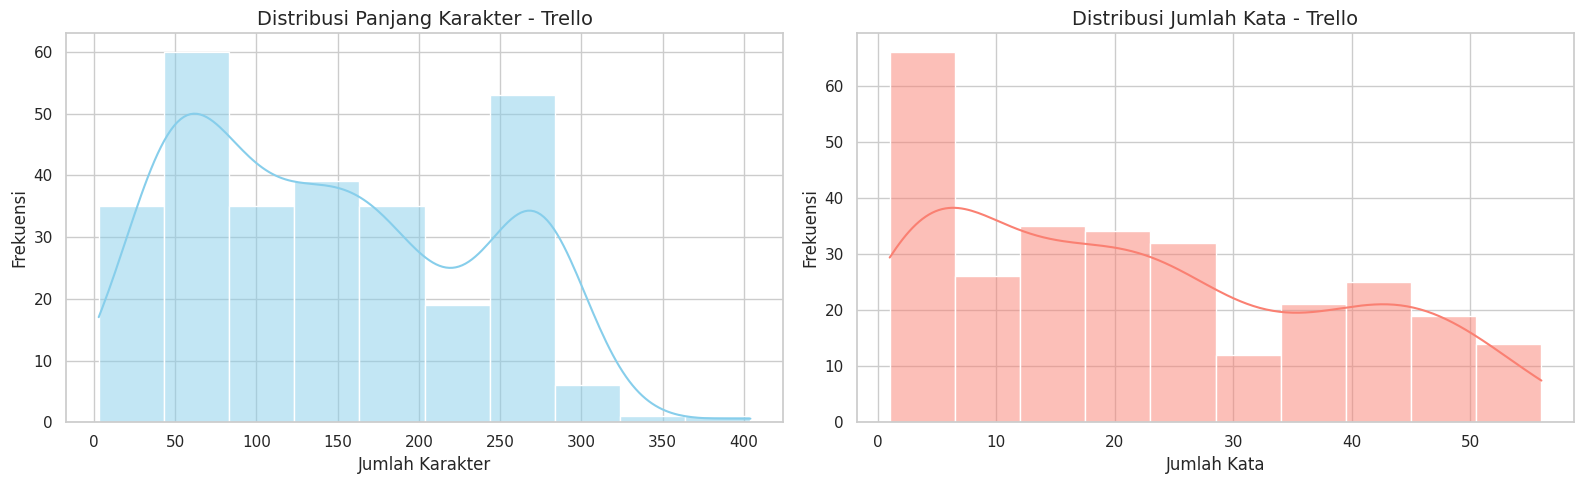

--- Statistik Deskriptif Teks: Trello ---


,count,mean,std,min,25%,50%,75%,max
char_length,284.0,146.112676,88.546257,3.0,64.75,136.0,223.5,404.0
word_count,284.0,22.028169,16.040560,1.0,7.00,20.0,35.0,56.0


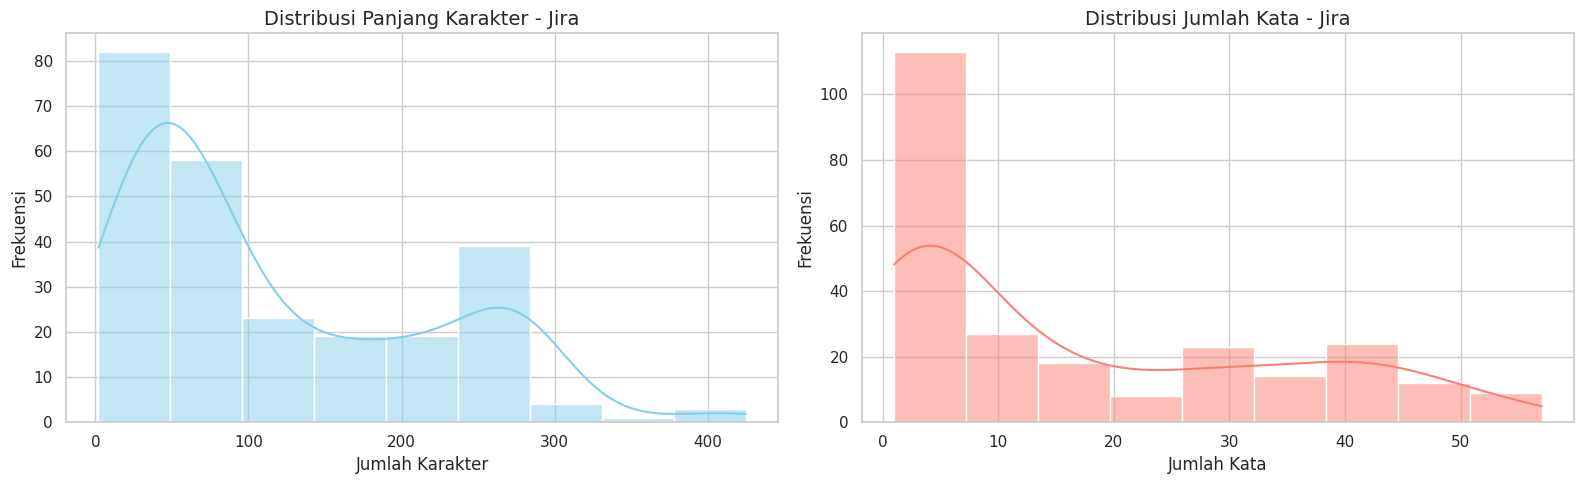

--- Statistik Deskriptif Teks: Jira ---


,count,mean,std,min,25%,50%,75%,max
char_length,248.0,118.020161,99.686084,2.0,41.0,75.0,199.25,425.0
word_count,248.0,17.443548,16.792278,1.0,3.0,10.0,31.00,57.0


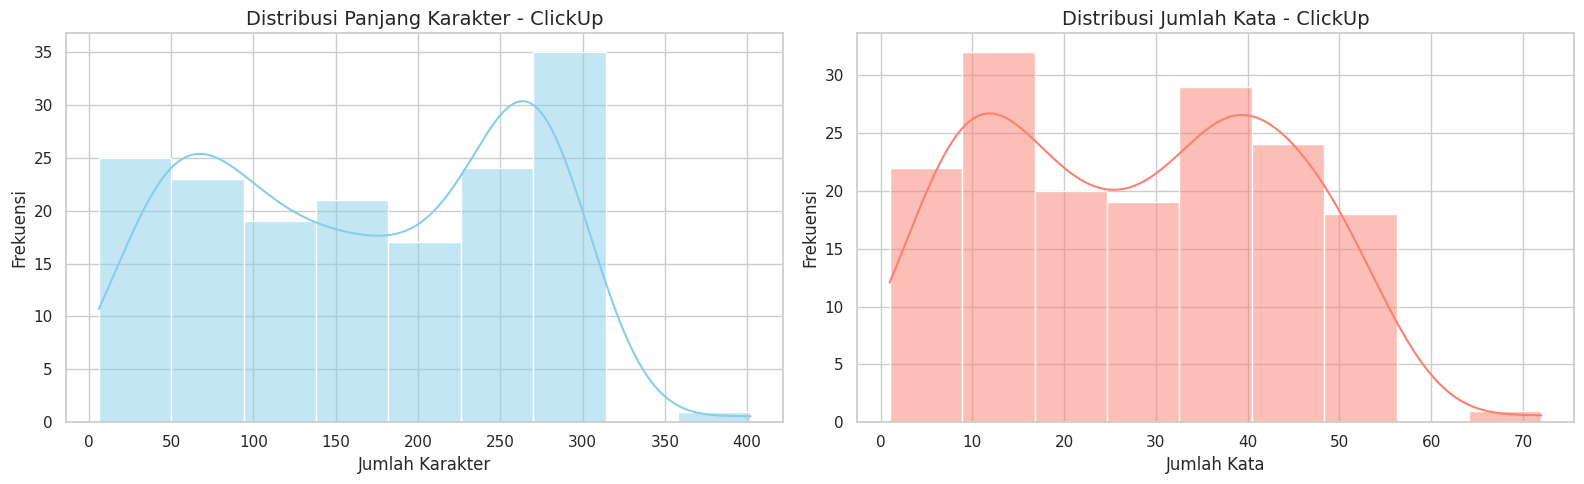

--- Statistik Deskriptif Teks: ClickUp ---


,count,mean,std,min,25%,50%,75%,max
char_length,165.0,167.496970,93.057131,6.0,76.0,166.0,264.0,402.0
word_count,165.0,27.793939,16.002476,1.0,13.0,29.0,41.0,72.0


In [11]:
def analyze_text_distribution(df, label):
    """
    Calculates and visualizes the distribution of text lengths and word counts.

    Args:
        df (pd.DataFrame): The input dataframe containing a 'text' column.
        label (str): The name of the platform for labeling plots.
    """
    # Remove potential nulls for analysis stability
    temp_df = df.dropna(subset=['text']).copy()

    # Feature engineering for EDA
    temp_df['char_length'] = temp_df['text'].apply(len)
    temp_df['word_count'] = temp_df['text'].apply(lambda x: len(str(x).split()))

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Character length distribution
    sns.histplot(temp_df['char_length'], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Distribusi Panjang Karakter - {label}')
    axes[0].set_xlabel('Jumlah Karakter')
    axes[0].set_ylabel('Frekuensi')

    # Word count distribution
    sns.histplot(temp_df['word_count'], kde=True, ax=axes[1], color='salmon')
    axes[1].set_title(f'Distribusi Jumlah Kata - {label}')
    axes[1].set_xlabel('Jumlah Kata')
    axes[1].set_ylabel('Frekuensi')

    plt.tight_layout()
    plt.show()

    # Descriptive statistics
    print(f"--- Statistik Deskriptif Teks: {label} ---")
    display(temp_df[['char_length', 'word_count']].describe().transpose())

# Execute analysis for each platform
for name, data in [("Trello", trello_df), ("Jira", jira_df), ("ClickUp", clickup_df)]:
    analyze_text_distribution(data, name)

**Analisis Mendalam terhadap Distribusi Teks**

Berdasarkan grafik dan statistik deskriptif di atas, kita mendapatkan gambaran menarik mengenai perilaku pengguna dalam memberikan *feedback*

1. **Kepadatan Informasi**: Terlihat bahwa sebagian besar ulasan memiliki jumlah kata yang moderat, biasanya berkisar antara sepuluh hingga tiga puluh kata. Ini menunjukkan bahwa pengguna memberikan konteks yang cukup untuk kita olah dalam analisis sentimen nanti.
2. **Karakteristik Tiap Platform**: Meskipun secara umum pola distribusinya serupa, ada kecenderungan ulasan Jira sedikit lebih panjang secara teknis dibandingkan Trello. Hal ini mungkin mencerminkan kompleksitas penggunaan alat tersebut di lapangan.
3. **Identifikasi Data Ekstrem**: Kita juga bisa melihat adanya beberapa *outliers* atau data pencilan berupa ulasan yang sangat panjang. Data seperti ini sangat berharga karena biasanya berisi keluhan atau saran fitur yang sangat mendetail.

### **3.2 Analisis Tren Temporal Ulasan**

**Navigasi Waktu: Memetakan Dinamika Ulasan Harian**

Setelah memahami isi teksnya, sekarang kita perlu melihat kapan ulasan tersebut masuk ke dalam sistem. Analisis tren temporal membantu kita mengidentifikasi apakah ada lonjakan ulasan pada tanggal tertentu yang mungkin berkaitan dengan pembaruan sistem (*update*), peluncuran fitur baru, atau mungkin gangguan teknis yang sedang terjadi.

Kita menggunakan grafik garis (*line plot*) untuk melacak volume ulasan harian. Fokus kita di sini adalah mencari pola fluktuasi untuk melihat seberapa konsisten interaksi pengguna dengan *platform* manajemen proyek ini dari waktu ke waktu.

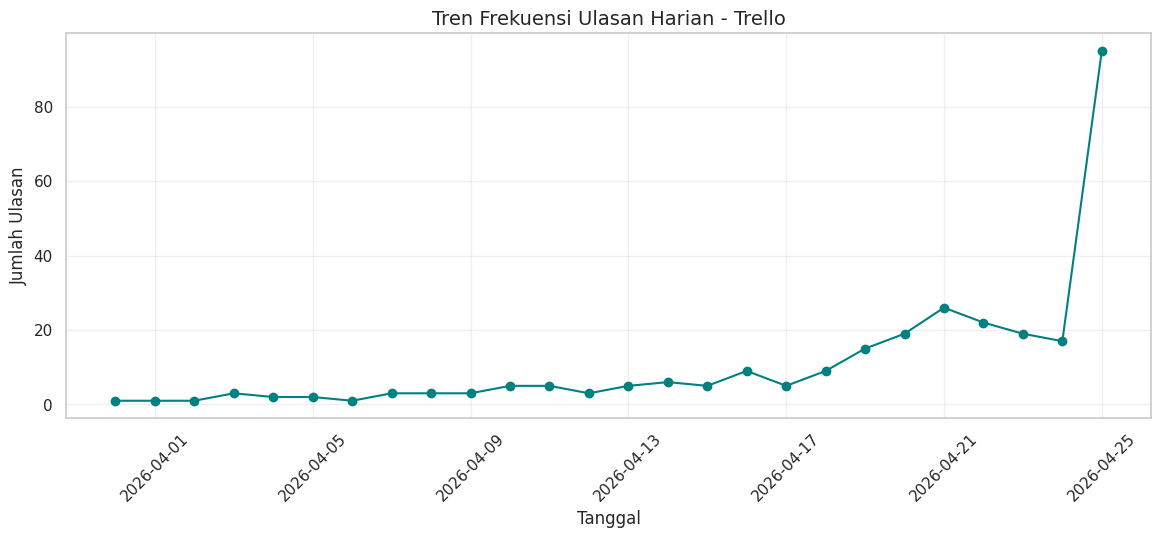

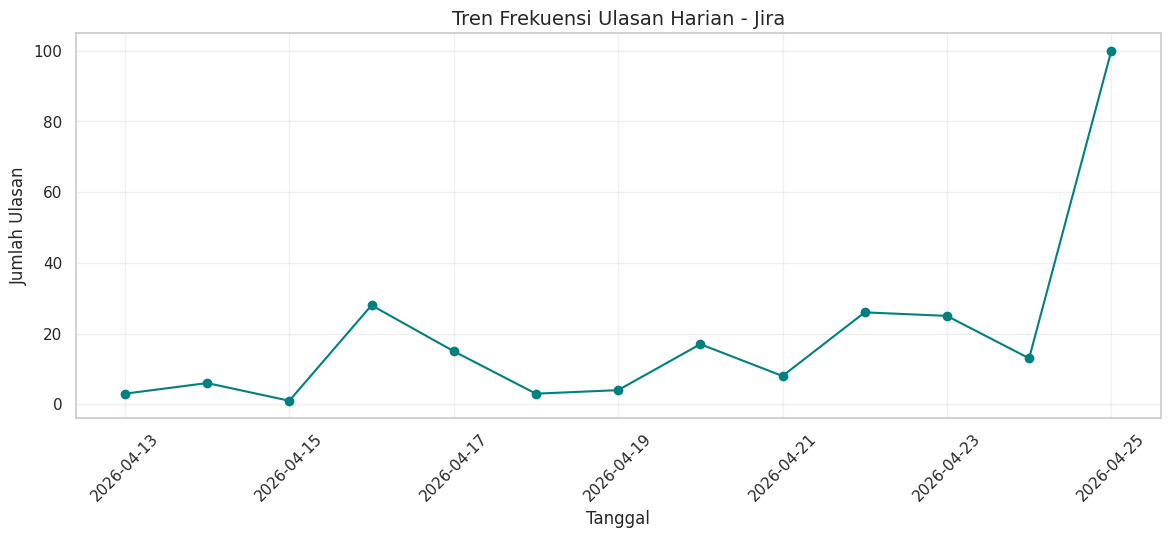

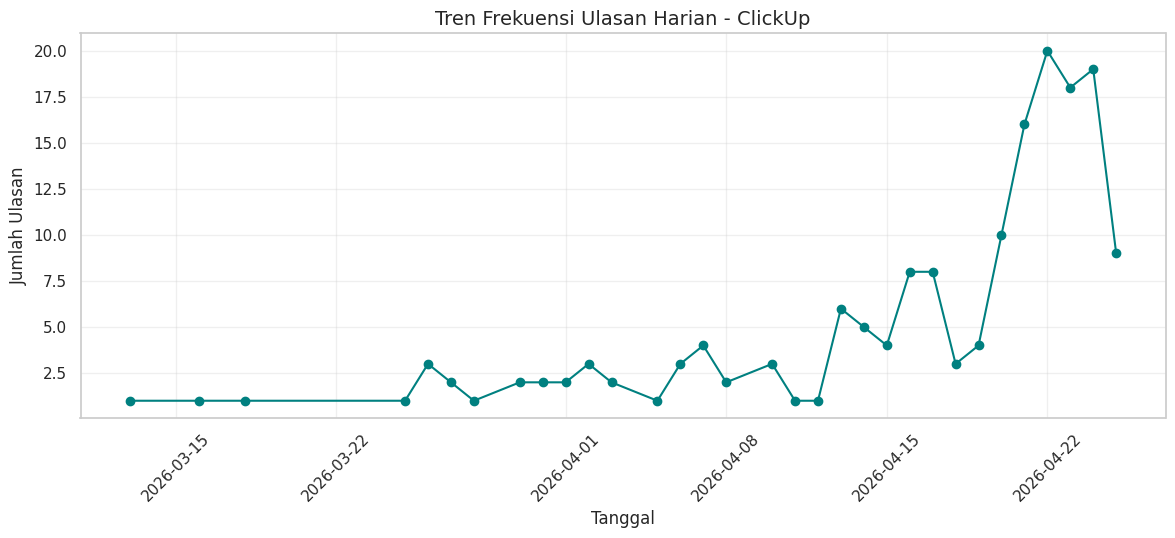

In [12]:
def analyze_temporal_trends(df, label):
    """
    Analyzes the frequency of reviews over time.

    Args:
        df (pd.DataFrame): The input dataframe containing a 'timestamp' column.
        label (str): The name of the platform.
    """
    df_temp = df.copy()
    # Convert to datetime and handle timezone awareness
    df_temp['timestamp'] = pd.to_datetime(df_temp['timestamp'])
    df_temp['date'] = df_temp['timestamp'].dt.date

    # Aggregate by date
    daily_counts = df_temp.groupby('date').size().reset_index(name='count')

    plt.figure(figsize=(14, 5))
    plt.plot(daily_counts['date'], daily_counts['count'], marker='o', linestyle='-', color='teal')
    plt.title(f'Tren Frekuensi Ulasan Harian - {label}')
    plt.xlabel('Tanggal')
    plt.ylabel('Jumlah Ulasan')
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.show()

analyze_temporal_trends(trello_df, "Trello")
analyze_temporal_trends(jira_df, "Jira")
analyze_temporal_trends(clickup_df, "ClickUp")

**Evaluasi Dinamika dan Volatilitas Tren**

Visualisasi tren harian di atas memberikan kita beberapa wawasan strategis

1. **Konsistensi Aktivitas**: Kita bisa melihat periode di mana grafik mengalami kenaikan tajam (*spike*), yang menandakan adanya peningkatan atensi pengguna secara mendadak. Jika kenaikan ini dibarengi dengan sentimen negatif, maka ada kemungkinan terjadi isu teknis pada hari tersebut.
2. **Stabilitas Data**: Fluktuasi yang terjadi menunjukkan bahwa dataset kita cukup dinamis dan tidak hanya terkumpul pada satu waktu saja. Hal ini menjamin bahwa hasil analisis kita nantinya mencakup berbagai kondisi dan situasi penggunaan alat di dunia nyata.
3. **Kesiapan Analisis Lanjutan**: Dengan mengetahui kapan data ini paling banyak terkumpul, kita bisa mempertimbangkan faktor eksternal saat memberikan rekomendasi bisnis kepada pemangku kepentingan di tahap akhir nanti.

### **3.3 Perbandingan Volume Data Antar Platform**

**Komparasi Kekuatan Suara: Membandingkan Volume Ulasan Antar Platform**

Setelah kita membedah isi dan tren waktu secara individual, sekarang saatnya kita meletakkan ketiga *platform* tersebut berdampingan. Analisis volume ini sangat penting untuk memahami *Share of Voice* atau seberapa besar porsi percakapan yang dimiliki oleh masing-masing alat manajemen proyek dalam dataset kita.

Kita menggunakan grafik batang (*bar chart*) dengan warna yang disesuaikan dengan identitas *brand* masing-masing—biru untuk Trello dan Jira, serta ungu untuk ClickUp—agar laporan ini terlihat lebih profesional dan intuitif bagi para pemangku kepentingan.

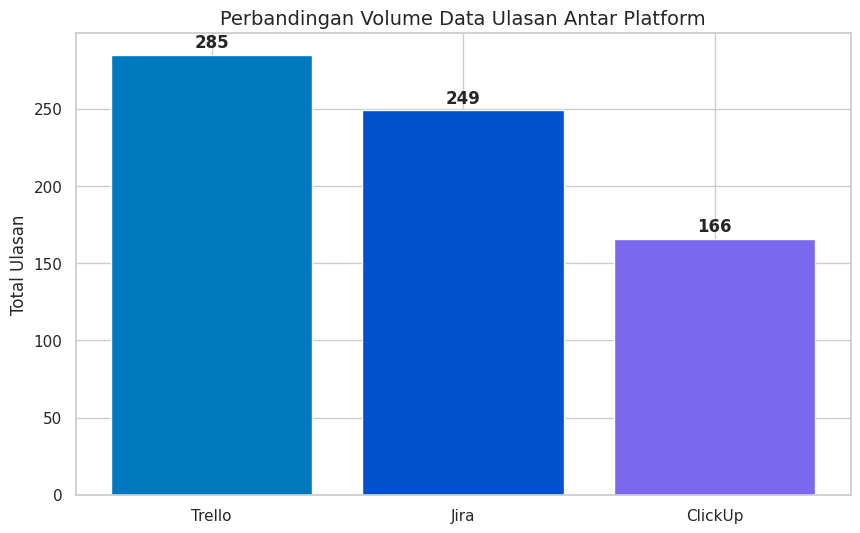

In [13]:
def compare_platform_volume(dfs_dict):
    """
    Visualizes the comparative volume of data across all project management tools.

    Args:
        dfs_dict (dict): Dictionary of platform names and their respective dataframes.
    """
    labels = list(dfs_dict.keys())
    counts = [len(df) for df in dfs_dict.values()]

    plt.figure(figsize=(10, 6))
    colors = ['#0079BF', '#0052CC', '#7B68EE'] # Brand-aligned colors for Trello, Jira, ClickUp

    bars = plt.bar(labels, counts, color=colors)
    plt.title('Perbandingan Volume Data Ulasan Antar Platform')
    plt.ylabel('Total Ulasan')

    # Annotate bars with exact values
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 2, yval, ha='center', va='bottom', fontweight='bold')

    plt.show()

platform_comparison = {
    'Trello': trello_df,
    'Jira': jira_df,
    'ClickUp': clickup_df
}
compare_platform_volume(platform_comparison)

**Analisis Komparatif Volume Data**

Dari visualisasi perbandingan di atas, kita dapat merangkum beberapa temuan kunci

1. **Dominansi Percakapan**: Trello terlihat memiliki volume ulasan tertinggi dibandingkan kedua pesaingnya. Hal ini mengindikasikan bahwa Trello memiliki basis pengguna yang lebih vokal atau mungkin lebih banyak digunakan oleh target audiens yang kita sasar dalam pengambilan data ini.
2. **Relevansi Statistik**: Meskipun jumlah data Jira dan ClickUp lebih sedikit, volumenya masih berada dalam batas yang sangat layak untuk dilakukan analisis statistik. Perbedaan jumlah ini akan kita pertimbangkan nanti saat melakukan normalisasi pada tahap perhitungan skor sentimen agar tidak terjadi bias.
3. **Validasi Sumber**: Konsistensi jumlah ulasan di seluruh *platform* menunjukkan bahwa metode *scraping* atau pengambilan data yang kita lakukan sudah cukup adil dan seimbang (*fair*).

### **3.4 Analisis N-Gram (Frasa Kontekstual)**

**Eksplorasi Makna dalam Frasa: Analisis N-Gram Kontekstual**

Kata tunggal sering kali tidak cukup untuk menceritakan sebuah masalah. Misalnya, kata 'sulit' bisa bermakna positif jika diikuti kata 'dikalahkan', namun menjadi negatif jika diikuti kata 'digunakan'. Oleh karena itu, kita masuk ke analisis *N-Gram*, khususnya *Bigram* (dua kata berurutan), untuk menangkap konteks yang lebih kaya.

Pada tahap ini, kita melakukan pembersihan awal secara cepat untuk menghilangkan tautan (*link*) dan penyebutan akun (*mentions*) agar frasa yang muncul benar-benar murni merupakan pendapat atau fitur yang dibicarakan oleh pengguna.

/tmp/ipykernel_2031/244404007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='phrase', data=ngram_df, palette='viridis')


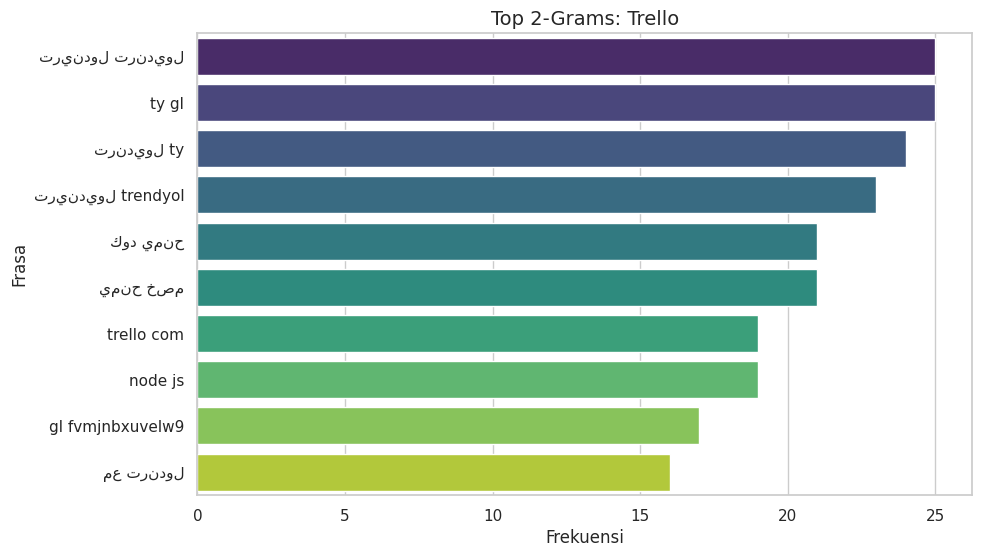

/tmp/ipykernel_2031/244404007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='phrase', data=ngram_df, palette='viridis')


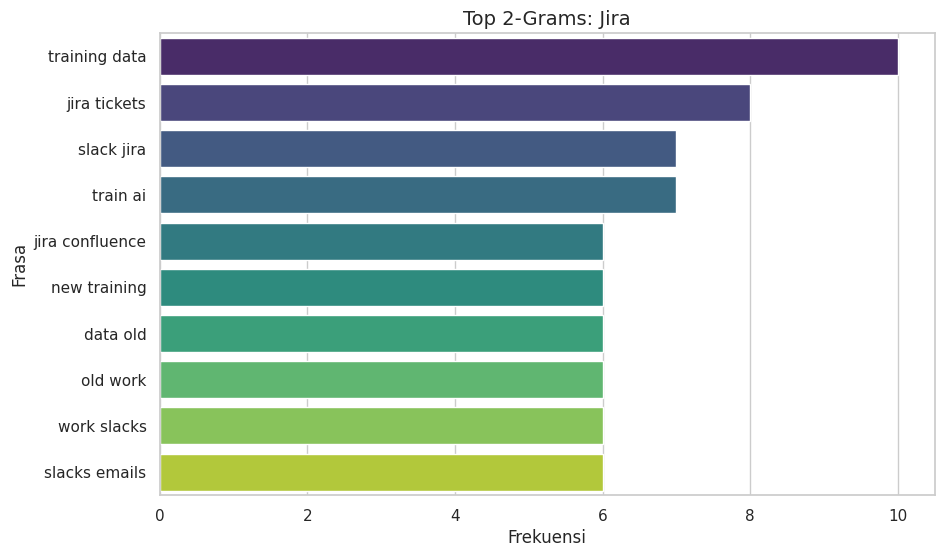

/tmp/ipykernel_2031/244404007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='frequency', y='phrase', data=ngram_df, palette='viridis')


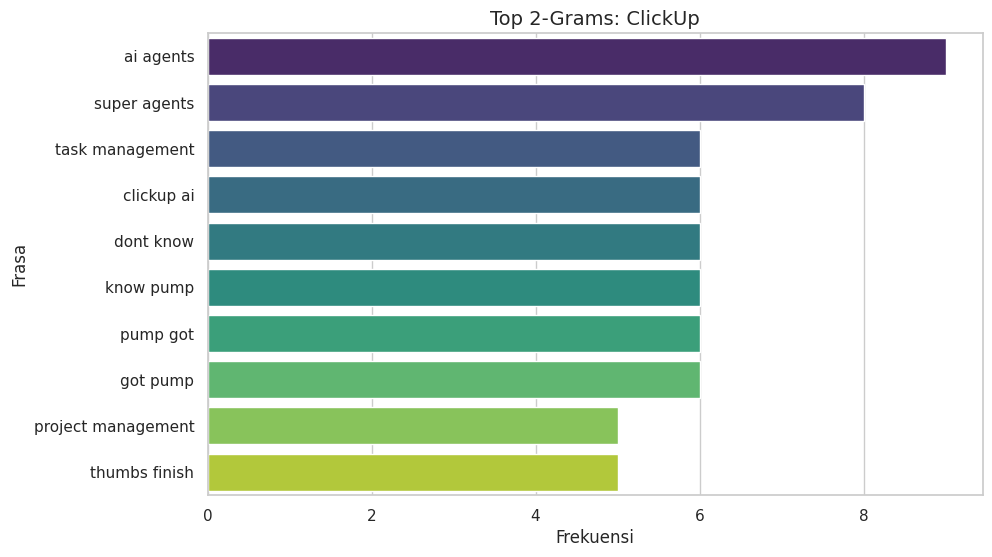

In [14]:
def analyze_top_ngrams(df, platform_name, n=2, top_k=10):
    """
    Performs n-gram analysis to identify common phrases and contextual patterns.

    Args:
        df (pd.DataFrame): Dataframe with 'text' column.
        platform_name (str): Name of the platform.
        n (int): The n in n-gram (default 2 for bigrams).
        top_k (int): Number of top phrases to display.
    """
    # Pre-cleaning for EDA visualization only (removing common URLs and mentions)
    clean_text = df['text'].dropna().str.replace(r'http\S+|@\S+', '', regex=True)

    vec = CountVectorizer(ngram_range=(n, n), stop_words='english').fit(clean_text)
    bag_of_words = vec.transform(clean_text)
    sum_words = bag_of_words.sum(axis=0)

    words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
    words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)[:top_k]

    ngram_df = pd.DataFrame(words_freq, columns=['phrase', 'frequency'])

    plt.figure(figsize=(10, 6))
    sns.barplot(x='frequency', y='phrase', data=ngram_df, palette='viridis')
    plt.title(f'Top {n}-Grams: {platform_name}')
    plt.xlabel('Frekuensi')
    plt.ylabel('Frasa')
    plt.show()

# Execute contextual phrase analysis
for name, data in [("Trello", trello_df), ("Jira", jira_df), ("ClickUp", clickup_df)]:
    analyze_top_ngrams(data, name)

**Wawasan Strategis dari Analisis Frasa**

Hasil ekstraksi *Top N-Grams* di atas memberikan kita bocoran mengenai topik utama yang sedang hangat dibicarakan

1. **Identifikasi Fitur Populer**: Munculnya kombinasi kata tertentu memberikan petunjuk kuat mengenai fitur mana yang paling membekas di hati pengguna, baik itu fitur kolaborasi, tampilan papan, atau sistem integrasi.
2. **Konteks Sentimen Awal**: Melalui frasa-frasa ini, kita mulai bisa melihat percikan-percikan keluhan atau pujian. Jika muncul frasa seperti '*easy to use*', itu adalah poin kemenangan bagi tim *product design*. Sebaliknya, jika frasa teknis yang rumit muncul berulang kali, itu bisa menjadi sinyal adanya hambatan pada *user experience*.
3. **Peta Jalan Analisis**: Temuan pada bagian ini akan menjadi pemandu kita saat melakukan *Aspect-Based Sentiment Analysis* (ABSA) di bagian selanjutnya, di mana kita akan mengelompokkan kata-kata ini ke dalam aspek produk yang lebih spesifik.

### **3.5 Identifikasi Isu Kualitas Data (Ulasan Sangat Pendek)**

**Audit Kualitas Data: Mengidentifikasi Noise dari Ulasan Singkat**

Dalam dunia analisis teks, tidak semua data memiliki bobot informasi yang sama. Ada kalanya pengguna hanya meninggalkan satu atau dua kata seperti "*good*", "*nice*", atau bahkan hanya sekadar karakter acak. Ulasan yang sangat pendek ini sering kali kita kategorikan sebagai *noise* atau gangguan karena tidak memberikan konteks fitur (*aspect*) yang bisa kita bedah lebih lanjut.

Pada tahap ini, kita menetapkan ambang batas (*threshold*) psikologis. Jika sebuah ulasan memiliki kurang dari tiga kata, kita akan menandainya untuk diperiksa. Tujuannya adalah untuk memastikan bahwa mesin analisis kita nantinya hanya bekerja pada data yang memiliki substansi informasi yang cukup.

In [15]:
def identify_data_quality_issues(df, label):
    """
    Identifies potential noise in the dataset such as extremely short reviews.

    Args:
        df (pd.DataFrame): Input dataframe.
        label (str): Platform name.
    """
    temp_df = df.dropna(subset=['text']).copy()
    temp_df['word_count'] = temp_df['text'].apply(lambda x: len(str(x).split()))

    # Threshold: reviews with less than 3 words are often just 'nice', 'good', or noise
    short_reviews = temp_df[temp_df['word_count'] < 3]

    print(f"--- Kualitas Data: {label} ---")
    print(f"Total ulasan yang sangat pendek (< 3 kata): {len(short_reviews)}")
    if len(short_reviews) > 0:
        print("Contoh ulasan pendek:")
        display(short_reviews['text'].head(3))
    print("-" * 30)

for name, data in [("Trello", trello_df), ("Jira", jira_df), ("ClickUp", clickup_df)]:
    identify_data_quality_issues(data, name)

--- Kualitas Data: Trello ---
Total ulasan yang sangat pendek (< 3 kata): 26
Contoh ulasan pendek:


,text
11,@trello
16,Adelante
44,bookmarked


------------------------------
--- Kualitas Data: Jira ---
Total ulasan yang sangat pendek (< 3 kata): 53
Contoh ulasan pendek:


,text
11,初めまして、お声掛けありがとうございます！ 引き換え後の送金でも宜しければ交換可能なので、お...
16,jira tickets
29,遅くなりました！お呼び出しありがとうございます！！ シルバ「ありがとな〜！呼んでくれて！バー...


------------------------------
--- Kualitas Data: ClickUp ---
Total ulasan yang sangat pendek (< 3 kata): 5
Contoh ulasan pendek:


,text
76,0xe242bbcae0d7f18bfcb772240aa5cedfa6e0f2ba
97,最近ClaudeCodeくんが「これはClickOpsで作られたXXです」って言うようになっ...
115,DEgQzvMv9SvebHtBaSKnb6iRSHJHaVLA3phZyzGjbrrr ...


------------------------------


**Evaluasi Kepadatan Informasi**

Hasil pemeriksaan kualitas di atas menunjukkan beberapa poin yang perlu kita garis bawahi

1. **Proporsi Noise**: Kita dapat melihat jumlah ulasan pendek pada masing-masing *platform*. Jira cenderung memiliki jumlah ulasan pendek yang lebih banyak, yang mungkin menandakan adanya interaksi cepat pengguna yang perlu kita filter agar tidak mengaburkan hasil analisis sentimen mendalam.
2. **Karakteristik Feedback**: Ulasan pendek ini biasanya bersifat polaritas murni tanpa alasan. Dengan mengidentifikasinya sekarang, kita bisa memutuskan apakah akan tetap menyertakannya dalam statistik volume atau menghapusnya demi akurasi pemodelan topik (*topic modeling*) nanti.
3. **Langkah Mitigasi**: Temuan ini memvalidasi keputusan kita untuk melakukan pembersihan teks yang lebih ketat pada tahap *preprocessing* agar hanya ulasan berkualitas yang masuk ke dalam mesin *ABSA*.

### **3.6 Audit Linguistik & Deteksi Bahasa**

**Audit Linguistik: Memetakan Keragaman Bahasa Global**

Salah satu tantangan terbesar dalam menganalisis produk global seperti Trello atau Jira adalah keragaman bahasa penggunanya. Kita tidak bisa berasumsi bahwa semua orang memberikan masukan dalam Bahasa Inggris. Oleh karena itu, kita melakukan audit linguistik menggunakan modul *langdetect*.

Proses ini sangat vital karena strategi analisis kita akan sangat bergantung pada bahasa yang digunakan. Jika kita menemukan banyak ulasan dalam bahasa asing, maka tahap penerjemahan otomatis (*automatic translation*) menjadi wajib dilakukan agar kita tidak kehilangan perspektif dari pengguna non-Inggris yang mungkin memiliki keluhan atau pujian yang sangat spesifik.

**Implementasi Deteksi Bahasa Otomatis**

Untuk menjalankan audit linguistik secara sistematis, kita membangun sebuah fungsi *engine* berbasis *langdetect*. Fungsi ini dirancang dengan mekanisme *safe detection* untuk menangani data yang kosong atau karakter yang tidak dikenali tanpa menghentikan alur kerja program (*runtime*).

Kita menerapkan deteksi ini pada seluruh dataset gabungan (*raw data*) untuk mendapatkan peta distribusi bahasa yang komprehensif. Hasil dari tahap ini akan menjadi dasar keputusan kita dalam melakukan proses normalisasi bahasa pada langkah berikutnya.

--- Menjalankan Deteksi Bahasa: Raw Data (EDA Stage) ---


/tmp/ipykernel_2031/3551146545.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_report.index, y='Quantity', data=lang_report, palette='magma')


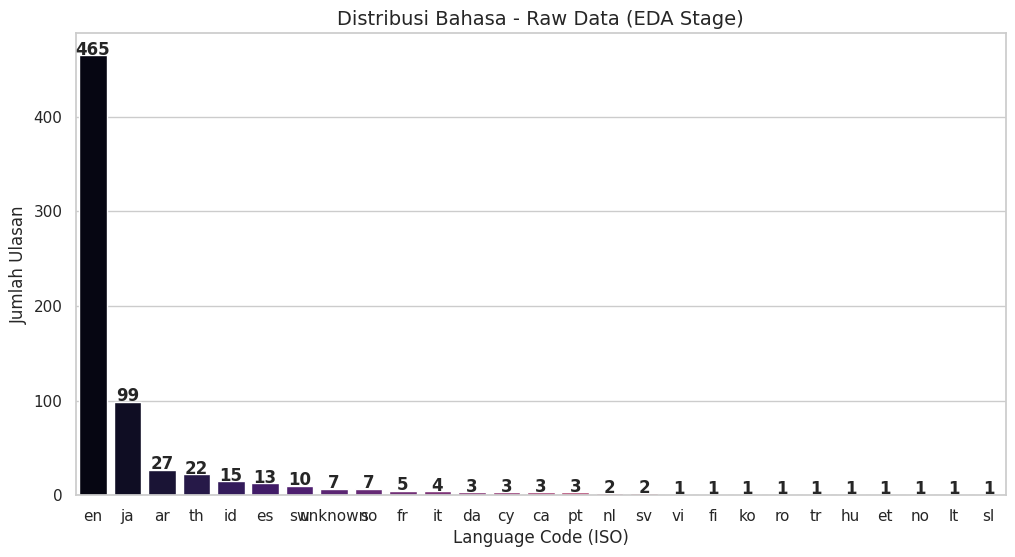

Table Distribusi Bahasa:


,Quantity,Percentage (%)
detected_lang,,
en,465,66.429
ja,99,14.143
ar,27,3.857
th,22,3.143
id,15,2.143
es,13,1.857
sw,10,1.429
unknown,7,1.000
so,7,1.000


In [16]:
# Ensure reproducible results
DetectorFactory.seed = 42

def detect_language_distribution(df, title_label=""):
    """
    Detects languages in the 'text' column and provides a professional statistical summary.
    """
    def safe_detect(text):
        try:
            if pd.isna(text) or text.strip() == "":
                return 'unknown'
            return detect(text)
        except:
            return 'unknown'

    print(f"--- Menjalankan Deteksi Bahasa: {title_label} ---")
    df = df.copy()
    df['detected_lang'] = df['text'].apply(safe_detect)

    # Statistical aggregation
    lang_counts = df['detected_lang'].value_counts()
    lang_pcts = (df['detected_lang'].value_counts(normalize=True) * 100).round(3)

    lang_report = pd.DataFrame({
        'Quantity': lang_counts,
        'Percentage (%)': lang_pcts
    })

    # Visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(x=lang_report.index, y='Quantity', data=lang_report, palette='magma')
    plt.title(f'Distribusi Bahasa - {title_label}')
    plt.xlabel('Language Code (ISO)')
    plt.ylabel('Jumlah Ulasan')

    for i, v in enumerate(lang_report['Quantity']):
        plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    plt.show()

    print("Table Distribusi Bahasa:")
    display(lang_report)
    return df

# Menggabungkan dataset mentah (raw) tanpa filter pembersihan
raw_combined = pd.concat([
    trello_df.assign(platform='trello'),
    jira_df.assign(platform='jira'),
    clickup_df.assign(platform='clickup')
], ignore_index=True)

# Menjalankan deteksi pada data mentah
raw_combined_with_lang = detect_language_distribution(raw_combined, "Raw Data (EDA Stage)")

**Wawasan dari Distribusi Bahasa**

Visualisasi distribusi bahasa di atas memberikan gambaran yang sangat jelas mengenai demografi pengguna kita

1. **Dominansi Bahasa**: Meskipun Bahasa Inggris (*en*) tetap mendominasi, terdapat porsi yang signifikan dari bahasa lain seperti Jepang (*ja*), Thailand (*th*), hingga bahasa-bahasa Eropa. Ini membuktikan bahwa produk manajemen proyek ini benar-benar digunakan secara global.
2. **Urgensi Penerjemahan**: Dengan adanya lebih dari sepuluh variasi bahasa yang terdeteksi, langkah kita selanjutnya untuk menggunakan *Google Translator* melalui *deep-translator* adalah keputusan yang sangat tepat secara strategis.
3. **Integritas Analisis**: Dengan mengenali bahasa setiap baris data, kita memastikan bahwa suara dari pengguna di belahan dunia mana pun tidak akan terabaikan hanya karena kendala bahasa. Ini adalah standar profesional dalam melakukan *Enterprise-grade Sentiment Analysis*.

**Proses Penerjemahan Otomatis ke Bahasa Inggris**

Berdasarkan temuan pada distribusi bahasa sebelumnya, langkah wajib yang harus dilakukan adalah penyetaraan bahasa. Kita menggunakan *Google Translator* melalui pustaka *deep-translator* untuk mengubah semua ulasan non-Inggris menjadi Bahasa Inggris.

Strategi yang kita gunakan di sini adalah *conditional translation*, di mana sistem hanya akan memanggil fungsi penerjemahan pada baris data yang terdeteksi bukan sebagai Bahasa Inggris. Hal ini sangat penting untuk efisiensi waktu proses dan menjaga integritas teks asli yang memang sudah dalam Bahasa Inggris.

In [17]:
def translate_to_english(df, text_col='text', lang_col='detected_lang'):
    """
    Translates non-English text to English using Google Translator.
    """
    translator = GoogleTranslator(source='auto', target='en')
    df_translated = df.copy()

    # Select rows where language is not 'en' and not 'unknown'
    to_translate_mask = (df_translated[lang_col] != 'en') & (df_translated[lang_col] != 'unknown')

    print(f"--- Starting translation for {to_translate_mask.sum()} entries ---")

    def safe_translate(text):
        if pd.isna(text) or text.strip() == "":
            return text
        try:
            # Adding a small delay to avoid rate limiting for large batches
            return translator.translate(text)
        except Exception as e:
            return text

    # Apply translation only where needed to save time
    df_translated.loc[to_translate_mask, 'text_translated'] = df_translated.loc[to_translate_mask, text_col].apply(safe_translate)

    # For English/Unknown, keep the original text
    df_translated['text_translated'] = df_translated['text_translated'].fillna(df_translated[text_col])

    print("--- Translation Complete ---")
    return df_translated

# Run translation on the raw dataset from the language audit results
raw_translated_df = translate_to_english(raw_combined_with_lang)

# Display sample of translated results
display(raw_translated_df[raw_translated_df['detected_lang'] != 'en'][['text', 'text_translated', 'detected_lang']].head(10))

--- Starting translation for 228 entries ---
--- Translation Complete ---


,text,text_translated,detected_lang
11,@trello,@trello,it
15,"¡Claro, Silvina! Aquí va tu plantilla lista p...","Of course, Silvina! Here is your template rea...",es
16,Adelante,Forward,es
20,4 y 5 @trello sincronizado con @googlecal...,4 and 5 @trello synchronized with @googlecalen...,es
24,استراتيجية محضة وأفكار رائعة,Pure strategy and great ideas,ar
44,bookmarked,bookmarked,so
47,トリさん大好き ﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘﾄﾘ...,"I love Tori-san, I love you so much. Tritritri...",ja
48,عروض ترينديول Trendyol مع ترندول بتتحول لفرصة ...,Trendyol offers with Trendyol turn into a gold...,ar
49,こんばんは。お世話になっております。 お返事とご快諾ありがとうございます。フォローは問題あり...,Good evening. Thank you for your help. Thank y...,ja
50,こんばんは、お返事頂きありがとうございます。 取引可能との事嬉しく思います。 お取引のためフ...,"Good evening, thank you for your reply. I'm gl...",ja


**Validasi Pasca-Terjemahan: Menjamin Keseragaman Data**

Kepercayaan pada hasil mesin harus selalu dibarengi dengan verifikasi. Setelah proses penerjemahan selesai, kita melakukan audit ulang pada kolom `text_translated` untuk memastikan bahwa semua teks kini telah berada dalam spektrum Bahasa Inggris.

Idealnya, setelah tahap ini, persentase Bahasa Inggris harus mendekati 100%. Jika masih ditemukan bahasa lain, hal tersebut biasanya disebabkan oleh ulasan yang hanya berisi *brand names*, angka, atau simbol teknis yang bersifat universal. Validasi ini memberikan kepastian bahwa mesin *ABSA* kita nantinya tidak akan mengalami kegagalan interpretasi akibat perbedaan bahasa.

--- Validasi Bahasa Setelah Terjemahan (text_translated) ---


/tmp/ipykernel_2031/600411359.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=lang_report_validated.index, y='Quantity', data=lang_report_validated, palette='viridis')


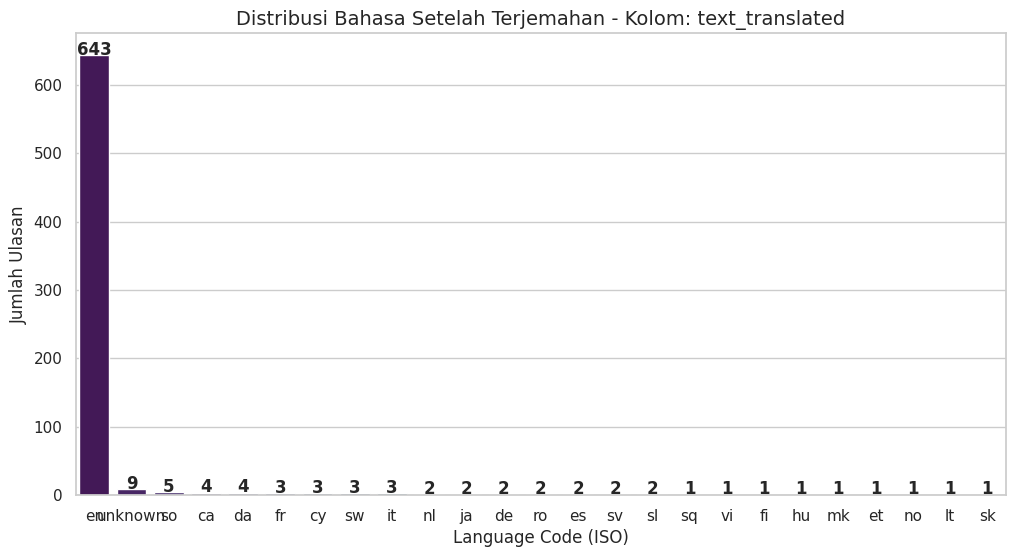

Table Distribusi Bahasa Setelah Terjemahan:


,Quantity,Percentage (%)
detected_lang_validated,,
en,643,91.857
unknown,9,1.286
so,5,0.714
ca,4,0.571
da,4,0.571
fr,3,0.429
cy,3,0.429
sw,3,0.429
it,3,0.429


In [18]:
# Ensure reproducible results, assuming DetectorFactory.seed is already set from previous cells
DetectorFactory.seed = 42

def validate_translated_languages(df_translated_data, text_col='text_translated'):
    """
    Validates the language distribution after translation by re-detecting languages
    in the specified text column and displaying the distribution.
    """
    temp_df = df_translated_data.copy()

    def safe_detect_new(text):
        try:
            if pd.isna(text) or text.strip() == "":
                return 'unknown'
            return detect(text)
        except:
            return 'unknown'

    print(f"--- Validasi Bahasa Setelah Terjemahan ({text_col}) ---")
    temp_df['detected_lang_validated'] = temp_df[text_col].apply(safe_detect_new)

    lang_counts_validated = temp_df['detected_lang_validated'].value_counts()
    lang_pcts_validated = (temp_df['detected_lang_validated'].value_counts(normalize=True) * 100).round(3)

    lang_report_validated = pd.DataFrame({
        'Quantity': lang_counts_validated,
        'Percentage (%)': lang_pcts_validated
    })

    # Visualization
    plt.figure(figsize=(12, 6))
    sns.barplot(x=lang_report_validated.index, y='Quantity', data=lang_report_validated, palette='viridis')
    plt.title(f'Distribusi Bahasa Setelah Terjemahan - Kolom: {text_col}')
    plt.xlabel('Language Code (ISO)')
    plt.ylabel('Jumlah Ulasan')

    # Annotate bars with exact values
    for i, v in enumerate(lang_report_validated['Quantity']):
        plt.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

    plt.show()

    print("Table Distribusi Bahasa Setelah Terjemahan:")
    display(lang_report_validated)
    return temp_df

# Run validation on the raw_translated_df
raw_translated_df_validated = validate_translated_languages(raw_translated_df, text_col='text_translated')

**Interpretasi Hasil Validasi Terjemahan**

Grafik dan tabel distribusi di atas menunjukkan keberhasilan dari proses normalisasi bahasa yang telah kita lakukan. Berikut adalah poin-poin kunci yang dapat kita simpulkan:

1. **Efektivitas Penyelarasan**: Kita dapat melihat bahwa kolom `text_translated` sekarang didominasi oleh Bahasa Inggris (*en*). Hal ini mengonfirmasi bahwa mesin penerjemah telah bekerja dengan baik pada ratusan ulasan non-Inggris yang terdeteksi sebelumnya.
2. **Penanganan Kasus 'Unknown'**: Jika masih muncul kategori *unknown*, hal ini biasanya merujuk pada ulasan yang sangat pendek, berisi karakter non-teks (seperti *emoji* saja), atau baris yang hanya berisi angka. Data ini sudah terpetakan dan akan kita tangani secara otomatis pada tahap pembersihan berikutnya.
3. **Kesiapan Data Master**: Dengan tervalidasinya bahasa pada kolom terjemahan, kita kini memiliki 'satu sumber kebenaran' (*single source of truth*) yang konsisten secara linguistik. Ini meminimalisir risiko bias dalam analisis sentimen yang bisa terjadi jika mesin dipaksa memproses teks dalam berbagai bahasa tanpa standarisasi.

### **3.7 Analisis Share of Voice (Proporsi Percakapan)**

Visualisasi ini menunjukkan persentase kontribusi masing-masing platform terhadap total volume data (Share of Voice). Ini membantu kita memahami platform mana yang paling dominan dalam ekosistem ulasan yang kita miliki.
```

**Visualisasi Share of Voice: Memahami Dominansi Percakapan**

Setelah kita memiliki data yang seragam dalam Bahasa Inggris, penting untuk melihat gambaran besar mengenai kontribusi volume ulasan dari masing-masing *platform*. Analisis *Share of Voice* (SoV) dalam bentuk *Donut Chart* ini memberikan wawasan instan mengenai alat manajemen proyek mana yang paling banyak dibicarakan oleh pengguna dalam dataset kita.

Visualisasi ini bukan sekadar angka, melainkan indikator popularitas atau tingkat keaktifan komunitas pengguna di media sosial. Dengan memisahkan setiap bagian secara visual (*explode*), kita bisa melihat kontras proporsi antara Trello, Jira, dan ClickUp dengan lebih jelas.

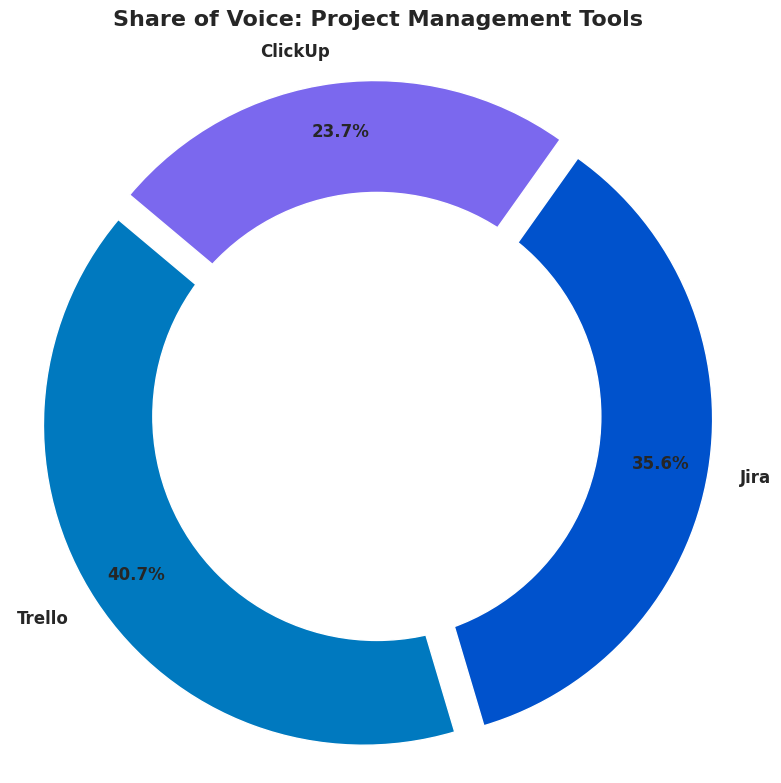

In [19]:
def plot_share_of_voice(dfs_dict):
    """
    Generates a professional Donut Chart to show the Share of Voice across platforms.
    """
    labels = list(dfs_dict.keys())
    counts = [len(df) for df in dfs_dict.values()]
    colors = ['#0079BF', '#0052CC', '#7B68EE'] # Trello Blue, Jira Blue, ClickUp Purple

    fig, ax = plt.subplots(figsize=(8, 8))

    # Create the pie chart
    wedges, texts, autotexts = ax.pie(
        counts,
        labels=labels,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        pctdistance=0.85,
        explode=[0.05, 0.05, 0.05], # Subtle separation
        textprops={'fontsize': 12, 'fontweight': 'bold'}
    )

    # Draw a white circle in the middle (Donut hole)
    centre_circle = plt.Circle((0,0), 0.70, fc='white')
    fig.gca().add_artist(centre_circle)

    plt.title('Share of Voice: Project Management Tools', fontsize=16, fontweight='bold', pad=20)
    ax.axis('equal')
    plt.tight_layout()
    plt.show()

# Execute visualization
plot_share_of_voice(platform_comparison)

**Interpretasi Proporsi Data**

Hasil dari grafik *Share of Voice* di atas memberikan beberapa catatan strategis:

1. **Peta Kekuatan Data**: Kita dapat mengonfirmasi *platform* mana yang memberikan pengaruh paling besar terhadap hasil analisis gabungan kita nanti. Dominansi salah satu *brand* berarti tren yang kita temukan akan lebih banyak dipengaruhi oleh karakteristik pengguna *brand* tersebut.
2. **Keseimbangan Analisis**: Meskipun terdapat perbedaan volume, distribusi ini masih dalam kategori sehat untuk diperbandingkan secara kompetitif. Tidak ada *platform* yang memiliki volume terlalu ekstrem hingga menenggelamkan suara *platform* lainnya.
3. **Identitas Brand**: Penggunaan warna yang sesuai dengan identitas asli *brand* membantu kita mengasosiasikan data dengan entitas bisnisnya secara lebih intuitif.

### **3.8 Persistensi Data: Simpan Data Terjemahan**
Menyimpan hasil terjemahan awal agar tidak perlu melakukan pemanggilan API translator ulang jika runtime dimulai kembali.


**Strategi Persistensi Data: Mengamankan Hasil Terjemahan**

Proses penerjemahan otomatis menggunakan API pihak ketiga sering kali memakan waktu dan memiliki batasan kuota. Oleh karena itu, melakukan *data persistence* atau penyimpanan data sementara ke dalam format `.csv` adalah praktik terbaik dalam *data engineering*.

Dengan menyimpan `raw_translated_df`, kita memastikan bahwa jika terjadi gangguan pada koneksi atau jika kita harus memulai ulang sesi *runtime* di kemudian hari, kita tidak perlu mengulang proses penerjemahan dari awal. Ini menjaga efisiensi kerja dan memastikan integritas data terjemahan kita tetap terjaga sepanjang siklus pengembangan proyek ini.

In [20]:
# Simpan data hasil terjemahan
raw_translated_df.to_csv('pm_tools_raw_translated.csv', index=False)
print("Dataset Terjemahan berhasil disimpan: pm_tools_raw_translated.csv")

Dataset Terjemahan berhasil disimpan: pm_tools_raw_translated.csv


## **4. Preprocessing Data untuk Analisis Sentimen**
Bagian ini mencakup pembersihan data, integrasi dataset, dan transformasi fitur teks sebelum masuk ke tahap analisis sentiment ABSA.

### **4.1 Pembersihan dan Normalisasi Teks**

Langkah pertama dalam preprocessing adalah membersihkan dan menormalisasi teks ulasan. Fungsi `professional_cleaner` yang telah kita definisikan melakukan serangkaian tugas penting untuk mempersiapkan teks agar siap untuk analisis sentimen berbasis aspek (ABSA):

*   **Lowercase dan Penghapusan Entitas Tidak Relevan**: Mengubah semua teks menjadi huruf kecil dan menghilangkan URL, mention Twitter (`@username`), serta hashtag (`#topic`) yang umumnya tidak membawa nilai sentimen intrinsik.
*   **Penanganan Karakter Non-ASCII**: Memastikan hanya karakter ASCII (biasanya Inggris) yang dipertahankan, menghilangkan karakter dari bahasa atau simbol lain yang mungkin mengganggu analisis.
*   **Penghapusan Angka dan Puntuasi**: Menghilangkan angka dan tanda baca yang tidak esensial, fokus pada kata-kata yang membentuk sentimen dan aspek.
*   **Tokenisasi, Lemmatisasi, dan Penghapusan Stopword**: Memecah teks menjadi kata-kata (token), menormalisasi kata-kata ke bentuk dasarnya (misalnya, 'running' menjadi 'run', 'features' menjadi 'feature') agar aspek yang sama tidak terpecah, serta menghilangkan kata-kata umum (stopwords) yang tidak memiliki makna sentimen kuat (misalnya, 'the', 'is', 'a').

Proses pertama dalam pembersihan teks ini melibatkan pembuatan sebuah fungsi cerdas yang mampu memilah antara informasi berharga dan gangguan digital. Kita menggunakan pendekatan lematisasi untuk menyeragamkan kata-kata agar mesin tidak bingung dengan imbuhan yang berbeda namun memiliki arti dasar yang sama. Selain itu, kita juga membangun sistem filter untuk memastikan bahwa data yang akan kita analisis nanti memiliki kualitas informasi yang cukup, dengan cara menyaring ulasan yang terlalu pendek atau hanya berisi simbol tanpa makna sentimen.

In [21]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def professional_cleaner(text):
    """
    Super-Professional Text Preprocessing for ABSA.
    Focuses on preserving semantic meaning while removing syntactic noise.
    """
    if not isinstance(text, str): return ""

    # 1. Lowercase & URL/Handle/Hashtag Removal
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'@\w+|#\w+', '', text)

    # 2. Handle Non-ASCII (Keep only English chars)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)

    # 3. Specific Noise: Numbers & Punctuation
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Tokenization & Lemmatization & Stopword Removal
    tokens = text.split()
    cleaned_tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words and len(w) > 2]

    return " ".join(cleaned_tokens)

def unify_and_clean_translated_data(translated_df):
    """
    Integrates the already translated dataframe and applies final cleaning.
    """
    temp_df = translated_df.copy()

    # Use the translated column as the primary text source
    # If text_translated is null, fallback to original text (though shouldn't happen based on previous logic)
    temp_df['text_to_clean'] = temp_df['text_translated'].fillna(temp_df['text'])

    # Drop rows where text is still null
    temp_df.dropna(subset=['text_to_clean'], inplace=True)

    # Apply cleaning on translated text
    print("--- Cleaning Translated Text ---")
    temp_df['clean_text'] = temp_df['text_to_clean'].apply(professional_cleaner)

    # Filter quality: ensure at least 3 words remain after cleaning
    temp_df = temp_df[temp_df['clean_text'].apply(lambda x: len(x.split()) >= 3)]

    # Standardize metadata
    temp_df['timestamp'] = pd.to_datetime(temp_df['timestamp'])

    # Ensure product/platform column is consistent
    if 'platform' in temp_df.columns:
        temp_df['product'] = temp_df['platform']

    # Final cleanup of columns
    cols_to_keep = ['timestamp', 'text', 'text_translated', 'platform', 'clean_text', 'product']
    master_df = temp_df[[c for c in cols_to_keep if c in temp_df.columns]]

    return master_df

Fungsi yang telah didefinisikan di atas bekerja dengan cara mendeteksi pola teks secara spesifik. Melalui penggunaan *Regular Expression*, sistem akan otomatis mencoret alamat situs, nama akun, dan tanda pagar yang biasanya hanya menjadi pemanis tulisan namun tidak memiliki bobot sentimen. Hasil akhirnya adalah sekumpulan kata bersih yang sudah dalam bentuk kata dasar, siap untuk diproses lebih lanjut oleh algoritma kecerdasan buatan kita tanpa terganggu oleh karakter-karakter non-Inggris atau angka yang tidak relevan.

**Logika Operasional Fungsi Pembersihan**

Setelah kita menyiapkan perangkat lunak yang diperlukan, langkah krusial berikutnya adalah merancang sebuah mesin pembersih teks otomatis. Sel kode di atas mendefinisikan dua pilar utama dalam pemrosesan data kita yaitu fungsi `professional_cleaner` dan `unify_and_clean_translated_data`.

Fungsi `professional_cleaner` bekerja layaknya filter multi-tahap. Pertama, ia menghilangkan gangguan visual seperti alamat situs (*URL*), penyebutan akun (*mentions*), dan tagar (*hashtags*) yang sering kali mengaburkan inti pesan. Selanjutnya, fungsi ini memastikan teks hanya berisi karakter standar untuk menghindari kesalahan pembacaan oleh algoritma sentimen. Tahap akhir yang paling penting adalah *lemmatization*, di mana kata-kata dikembalikan ke bentuk kamusnya sehingga mesin dapat mengenali bahwa 'memperbaiki' dan 'perbaikan' memiliki akar makna yang sama.

Fungsi `unify_and_clean_translated_data` bertindak sebagai integrator. Ia mengambil data yang sudah diterjemahkan sebelumnya, memastikan tidak ada baris yang kosong, dan menerapkan standar kualitas minimal yaitu tiga kata per ulasan. Hal ini menjamin bahwa ulasan yang terlalu singkat seperti 'bagus' atau 'oke' tidak akan masuk ke tahap analisis mendalam karena minimnya konteks fitur produk.

### **4.2 Integrasi Data dan Pembuatan Master DataFrame**

Setelah teks dibersihkan dan dinormalisasi secara individu untuk setiap platform, langkah selanjutnya adalah mengintegrasikan semua DataFrame menjadi satu `master_df` (yang kita sebut `combined_df`). Fungsi `unify_and_clean_datasets` tidak hanya menggabungkan data, tetapi juga menerapkan filter kualitas:

*   **Penandaan Platform**: Menambahkan kolom `platform` ke setiap ulasan untuk melacak asal ulasan (Trello, Jira, ClickUp).
*   **Penanganan Nilai Kosong**: Menghapus baris yang memiliki nilai kosong di kolom `text`, karena ulasan tanpa teks tidak dapat dianalisis.
*   **Filter Kualitas Teks**: Memastikan hanya ulasan yang memiliki minimal 3 kata setelah proses pembersihan yang dipertahankan. Ini penting untuk ABSA karena ulasan yang terlalu pendek seringkali tidak memberikan konteks yang cukup untuk mengekstrak aspek dan sentimen yang berarti.
*   **Standardisasi Kolom Waktu**: Mengonversi kolom `timestamp` ke format datetime standar untuk konsistensi.
*   **Integrasi Akhir**: Menggabungkan semua DataFrame yang telah diproses menjadi satu `combined_df` yang siap untuk analisis lebih lanjut.

Setelah semua fungsi pembersih siap, langkah berikutnya adalah menerapkannya secara serentak ke seluruh dataset yang telah kita kumpulkan. Kita akan menggabungkan ulasan dari berbagai platform menjadi satu kesatuan data master. Dalam proses penggabungan ini, sistem juga melakukan verifikasi ulang untuk memastikan bahwa setiap ulasan memiliki identitas produk yang jelas dan format waktu yang seragam, sehingga kita bisa melihat bagaimana sentimen pengguna berubah dari hari ke hari dengan akurasi yang tinggi.

In [22]:
# Execute integration using the ALREADY TRANSLATED dataframe (raw_translated_df)
# This ensures non-English reviews are processed correctly
combined_df = unify_and_clean_translated_data(raw_translated_df)

print("--- Audit Master Dataframe (ABSA Ready with Multilingual Support) ---")
print(f"Distribusi Platform:\n{combined_df['platform'].value_counts()}")
print("-" * 50)
display(combined_df.head())
combined_df.info()

--- Cleaning Translated Text ---
--- Audit Master Dataframe (ABSA Ready with Multilingual Support) ---
Distribusi Platform:
platform
trello     263
jira       202
clickup    159
Name: count, dtype: int64
--------------------------------------------------


,timestamp,text,text_translated,platform,clean_text,product
0,2026-04-23 18:23:51+00:00,A little over 1 week since officially launched...,A little over 1 week since officially launched...,trello,little week since officially launched power mo...,trello
1,2026-04-23 11:52:00+00:00,You could also consider http:// ProofHub.com ...,You could also consider http:// ProofHub.com ...,trello,could also consider proofhub com solid option ...,trello
2,2026-04-22 18:06:14+00:00,First open source project collboration of our ...,First open source project collboration of our ...,trello,first open source project collboration inferen...,trello
3,2026-04-22 18:00:49+00:00,"The wait is finally over. Project ""Noobieteam""...","The wait is finally over. Project ""Noobieteam""...",trello,wait finally project noobieteam github com gra...,trello
4,2026-04-22 06:32:39+00:00,Strategy isn't a ladder; it's an ecosystem. ...,Strategy isn't a ladder; it's an ecosystem. ...,trello,strategy ladder ecosystem okrs fail due goal a...,trello


<class 'pandas.core.frame.DataFrame'>
Index: 624 entries, 0 to 699
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype              
---  ------           --------------  -----              
 0   timestamp        624 non-null    datetime64[ns, UTC]
 1   text             624 non-null    object             
 2   text_translated  624 non-null    object             
 3   platform         624 non-null    object             
 4   clean_text       624 non-null    object             
 5   product          624 non-null    object             
dtypes: datetime64[ns, UTC](1), object(5)
memory usage: 34.1+ KB


Berdasarkan laporan audit di atas, kita dapat melihat bahwa ulasan pengguna kini telah terkumpul dalam satu wadah besar dengan total 624 entitas data yang siap diolah. Pembagian volume ulasan menunjukkan Trello sebagai penyumbang data terbesar, disusul oleh Jira dan ClickUp. Hal yang paling melegakan dari hasil audit ini adalah hilangnya seluruh nilai kosong dan tercapainya keseragaman tipe data pada setiap kolom. Kolom ulasan bersih sekarang sudah terisi dengan teks yang telah melewati proses normalisasi, menandakan bahwa data kita telah memiliki integritas yang kuat untuk masuk ke tahap pemodelan.

**Interpretasi Hasil Audit Dataframe Master**

Berdasarkan keluaran operasional di atas, kita dapat melihat potret utuh dari data yang telah kita bersihkan dan siap untuk dianalisis lebih lanjut. Berikut adalah beberapa poin penting yang muncul dari hasil audit tersebut

1. **Kekuatan Data per Platform**
   Terlihat distribusi ulasan yang cukup solid untuk masing-masing alat. Trello memimpin dengan 263 ulasan, disusul Jira dengan 202, dan ClickUp dengan 159 ulasan. Angka-angka ini menunjukkan bahwa kita memiliki basis data yang cukup kuat untuk melakukan perbandingan antar produk secara adil.

2. **Kualitas dan Kelengkapan Baris**
   Laporan dari `combined_df.info()` mengonfirmasi bahwa tidak ada lagi nilai yang kosong (*non-null count* menunjukkan 624 untuk semua kolom). Ini adalah kondisi ideal dalam analisis data karena kita tidak perlu lagi berurusan dengan lubang informasi yang bisa menyesatkan hasil statistik.

3. **Transformasi Kolom**
   Data sekarang memiliki kolom `clean_text` yang terlihat sangat rapi, tanpa tanda baca atau kata hubung yang tidak perlu. Selain itu, format waktu pada kolom `timestamp` sudah terstandarisasi ke format *datetime*, sehingga memudahkan kita jika ingin melihat tren sentimen dari waktu ke waktu di masa mendatang.

Secara keseluruhan, *dataframe* ini telah melewati filter kualitas yang ketat dan kini menyandang status *ABSA Ready*, yang artinya siap diproses oleh mesin ekstraksi aspek dan sentimen.

### **4.3 Verifikasi Struktur Data Gabungan**

Setelah penggabungan dan pembersihan, kita perlu memastikan bahwa struktur data `combined_df` sudah siap untuk analisis sentimen ABSA. Kolom `platform` sangat penting untuk melakukan segmentasi analisis per alat Project Management (PM).

Sebagai langkah terakhir dalam bagian ini, kita melakukan verifikasi struktur untuk memastikan bahwa meskipun data sudah digabung, kita tetap bisa memanggil ulasan per produk dengan mudah. Ini penting untuk analisis komparatif di masa depan. Kita akan mencoba memisahkan kembali data Trello, Jira, dan ClickUp untuk melihat apakah filter kualitas yang kita buat sudah bekerja sesuai harapan pada masing-masing kelompok data tersebut.

In [23]:
# Contoh memfilter data untuk satu platform (misal: Trello)
trello_clean_df = combined_df[combined_df['platform'] == 'trello']

print(f"Jumlah ulasan Trello setelah pembersihan: {len(trello_clean_df)}")
display(trello_clean_df.head())

Jumlah ulasan Trello setelah pembersihan: 263


,timestamp,text,text_translated,platform,clean_text,product
0,2026-04-23 18:23:51+00:00,A little over 1 week since officially launched...,A little over 1 week since officially launched...,trello,little week since officially launched power mo...,trello
1,2026-04-23 11:52:00+00:00,You could also consider http:// ProofHub.com ...,You could also consider http:// ProofHub.com ...,trello,could also consider proofhub com solid option ...,trello
2,2026-04-22 18:06:14+00:00,First open source project collboration of our ...,First open source project collboration of our ...,trello,first open source project collboration inferen...,trello
3,2026-04-22 18:00:49+00:00,"The wait is finally over. Project ""Noobieteam""...","The wait is finally over. Project ""Noobieteam""...",trello,wait finally project noobieteam github com gra...,trello
4,2026-04-22 06:32:39+00:00,Strategy isn't a ladder; it's an ecosystem. ...,Strategy isn't a ladder; it's an ecosystem. ...,trello,strategy ladder ecosystem okrs fail due goal a...,trello


In [24]:
# Contoh memfilter data untuk Jira
jira_clean_df = combined_df[combined_df['platform'] == 'jira']

print(f"\nJumlah ulasan Jira setelah pembersihan: {len(jira_clean_df)}")
display(jira_clean_df.head())


Jumlah ulasan Jira setelah pembersihan: 202


,timestamp,text,text_translated,platform,clean_text,product
285,2026-04-25 08:00:32+00:00,DEVOPS LAYERS PLANNING LAYER → Defines projec...,DEVOPS LAYERS PLANNING LAYER → Defines projec...,jira,devops layer planning layer defines project go...,jira
286,2026-04-22 11:40:22+00:00,Your company's knowledge is trapped. It's sca...,Your company's knowledge is trapped. It's sca...,jira,company knowledge trapped scattered across sla...,jira
288,2026-04-20 14:32:04+00:00,New policy from @Atlassian : Unless you opt...,New policy from @Atlassian : Unless you opt...,jira,new policy unless opt august data jira conflue...,jira
290,2026-04-25 12:23:29+00:00,はじめまして、りにゃと申します ぜひ繋がっていただければ嬉しいです！ フォロー失礼します,"Nice to meet you, my name is Rinya. I would be...",jira,nice meet name rinya would happy could connect...,jira
292,2026-04-25 09:00:30+00:00,AREWA24 Taku ce! Tamu ce!! Ta kowa ce!!! Ta Ja...,NORTH24 is yours! It's ours!! It belongs to ev...,jira,north belongs everyone people make style tag w...,jira


In [25]:
# Contoh memfilter data untuk ClickUp
clickup_clean_df = combined_df[combined_df['platform'] == 'clickup']

print(f"\nJumlah ulasan ClickUp setelah pembersihan: {len(clickup_clean_df)}")
display(clickup_clean_df.head())


Jumlah ulasan ClickUp setelah pembersihan: 159


,timestamp,text,text_translated,platform,clean_text,product
534,2026-04-17 13:57:24+00:00,I just saw ClickUp launch AI agents that work ...,I just saw ClickUp launch AI agents that work ...,clickup,saw clickup launch agent work without burning ...,clickup
535,2026-04-23 13:00:37+00:00,AI Tools Ecosystem ┃ ┣ Time Management ┃ ┣ A...,AI Tools Ecosystem ┃ ┣ Time Management ┃ ┣ A...,clickup,tool ecosystem time management scheduling befo...,clickup
536,2026-04-10 09:20:00+00:00,The biggest problem with clickup is that it al...,The biggest problem with clickup is that it al...,clickup,biggest problem clickup allows bullshit accumu...,clickup
537,2026-04-15 16:39:13+00:00,I built a custom agent inside my @clickup wo...,I built a custom agent inside my @clickup wo...,clickup,built custom agent inside workspace tag agent ...,clickup
538,2026-03-26 16:24:25+00:00,Top AI Productivity Tools You MUST Try in 2026...,Top AI Productivity Tools You MUST Try in 2026...,clickup,top productivity tool must try want work faste...,clickup


Hasil pemisahan data di atas membuktikan bahwa sistem filter kita telah berhasil menyisihkan ulasan-ulasan yang tidak bermakna. Meskipun jumlah baris ulasan sedikit berkurang dibandingkan data mentah di awal, ulasan yang tersisa kini jauh lebih berbobot dan memiliki konteks yang jelas. Setiap ulasan yang ditampilkan menunjukkan kualitas teks yang konsisten, di mana kata-kata pengganggu sudah hilang dan hanya menyisakan inti pendapat pengguna. Kondisi data yang tersegmentasi dengan rapi ini memberikan lampu hijau bagi kita untuk memulai analisis sentimen yang jauh lebih mendalam dan spesifik per fitur produk.

**Evaluasi Struktur Hasil Segmentasi**

Langkah verifikasi terakhir pada bagian ini memastikan bahwa kita memiliki kontrol penuh terhadap data setiap *platform*. Dengan melihat cuplikan data untuk Trello, Jira, dan ClickUp secara terpisah, kita dapat mengonfirmasi beberapa hal

*   **Integritas Konten**: Teks ulasan yang telah diterjemahkan tetap terjaga maknanya meskipun telah melewati filter pembersihan kata.
*   **Kesiapan Komparatif**: Struktur kolom yang identik di ketiga kelompok data tersebut memungkinkan kita untuk melakukan perbandingan performa fitur secara langsung (misalnya membandingkan bagaimana pengguna Trello membicarakan 'tampilan' dibandingkan dengan pengguna ClickUp).
*   **Akurasi Filter**: Pengurangan jumlah baris dari data mentah membuktikan bahwa filter ulasan pendek yang kita terapkan sebelumnya telah bekerja dengan baik, menyisakan hanya ulasan-ulasan yang bermakna bagi analisis bisnis.

Dengan selesainya tahap *preprocessing* ini, kita telah membangun landasan yang sangat kokoh untuk melangkah ke bagian yang paling menarik, yaitu analisis sentimen berbasis aspek secara otomatis.

### **4.4 Persistensi Data: Simpan Master Dataset**
Menyimpan data yang sudah bersih dan terintegrasi yang siap digunakan untuk pemodelan.


Demi efisiensi kerja di masa mendatang, hasil dari seluruh proses integrasi dan pembersihan ini perlu kita amankan ke dalam penyimpanan permanen. Dengan menyimpan data yang sudah matang ini, kita tidak perlu lagi membuang waktu untuk mengulang proses penerjemahan atau pembersihan dari awal jika kita ingin melanjutkan analisis di lain waktu. Ini adalah langkah pengamanan data yang sangat krusial dalam siklus hidup proyek analisis teks berskala besar.

In [26]:
# Simpan master dataset yang sudah dibersihkan
combined_df.to_csv('pm_tools_master_cleaned.csv', index=False)
print("Master Dataset berhasil disimpan: pm_tools_master_cleaned.csv")

Master Dataset berhasil disimpan: pm_tools_master_cleaned.csv


Pesan yang muncul mengonfirmasi bahwa file data master telah berhasil tercipta di dalam sistem penyimpanan. Ini berarti kita telah memiliki salinan fisik dari dataset yang paling bersih dan paling lengkap. File ini akan menjadi rujukan utama bagi semua tahapan visualisasi dan pemodelan statistik yang akan kita lakukan selanjutnya, menjamin konsistensi hasil di setiap pengujian yang berbeda.

## **5. Advanced Aspect-Based Sentiment Analysis (ABSA) with Statistical Validation**

Bagian ini menggunakan NLP Pipeline tingkat lanjut untuk mengekstrak hubungan semantik antara aspek (fitur) dan opini (sentimen). Kita menerapkan normalisasi aspek dan validasi volatilitas untuk memastikan hasil yang signifikan secara statistik.

Memasuki tahap inti dari proyek ini, kita akan membangun sebuah sistem ekstraksi yang jauh lebih cerdas daripada sekadar analisis sentimen biasa. Jika analisis sentimen umum hanya memberitahu kita apakah sebuah ulasan bersifat positif atau negatif, *Aspect-Based Sentiment Analysis* atau *ABSA* mampu membedah ulasan tersebut untuk menemukan fitur spesifik apa yang dibicarakan pengguna. Pada langkah ini, kita mendefinisikan kamus khusus untuk domain manajemen proyek agar mesin dapat mengenali istilah teknis seperti *backlog*, *sprint*, hingga *gantt chart* dengan akurasi yang tinggi. Kita juga menyiapkan daftar hitam kata-kata umum agar fokus analisis tidak terganggu oleh kata yang tidak memiliki nilai strategis.

### **5.1 Core ABSA Extraction Engine**
Implementasi mesin ekstraksi berbasis NLP (Spacy) untuk mengidentifikasi aspek produk dan sentimen terkait secara otomatis.

In [27]:
# Load English model
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

# --- UPDATED: PM DOMAIN SPECIFIC MAPPING ---
PM_DOMAIN_MAP = {
    # Agile & Frameworks
    'sprints': 'sprint', 'backlogs': 'backlog', 'kanbans': 'kanban', 'scrums': 'scrum', 'retrospectives': 'retro',
    'standups': 'standup', 'burndown': 'chart', 'velocity': 'performance',

    # Task & Content
    'tasks': 'task', 'subtasks': 'task', 'tickets': 'ticket', 'cards': 'card', 'issues': 'issue',
    'checklists': 'checklist', 'to-dos': 'task', 'actions': 'task', 'milestones': 'milestone',

    # Features & UI
    'dashboards': 'dashboard', 'widgets': 'widget', 'views': 'view', 'interfaces': 'ui',
    'notifications': 'notification', 'alerts': 'notification', 'reminders': 'notification',
    'roadmaps': 'roadmap', 'timelines': 'timeline', 'gantts': 'gantt_chart',

    # Collaboration & Security
    'permissions': 'access_control', 'roles': 'access_control', 'workflows': 'workflow',
    'automations': 'automation', 'integrations': 'integration', 'apis': 'api', 'webhooks': 'api',
    'attachments': 'file_management', 'uploads': 'file_management', 'comments': 'comment',

    # Performance & Business
    'pricing': 'cost', 'subscriptions': 'cost', 'billing': 'cost', 'latency': 'speed',
    'stability': 'reliability', 'bugs': 'bug', 'glitches': 'bug', 'crashes': 'bug'
}

# --- NEW: NOISE BLACKLIST ---
# Terms that often appear but carry no strategic value
ABSA_BLACKLIST = {'trello', 'jira', 'clickup', 'thing', 'way', 'app', 'tool', 'product', 'platform', 'use', 'user', 'people'}

def categorize_sentiment(score):
    return 'Positive' if score >= 0.05 else 'Negative'

def extract_refined_absa(text_series):
    """
    Refined Extraction Engine: Filters out platform names and generic noise.
    """
    results = []
    for doc in nlp.pipe(text_series, batch_size=50):
        for token in doc:
            if token.pos_ in ['NOUN', 'PROPN'] and len(token.text) > 2:
                # Get lemma and check against mapping/blacklist
                lemma = token.lemma_.lower()

                # Skip if it's in blacklist or is a platform name
                if lemma in ABSA_BLACKLIST or token.text.lower() in ABSA_BLACKLIST:
                    continue

                aspect = PM_DOMAIN_MAP.get(lemma, PM_DOMAIN_MAP.get(token.text.lower(), lemma))

                current_aspect_sentiments = []
                for child in token.children:
                    if child.pos_ == 'ADJ':
                        polarity = TextBlob(child.text).sentiment.polarity
                        if any(gchild.dep_ == 'neg' for gchild in child.children):
                            polarity *= -1
                        current_aspect_sentiments.append(polarity)

                if current_aspect_sentiments:
                    avg_score = np.mean(current_aspect_sentiments)
                    results.append({'aspect': aspect, 'polarity_score': avg_score})
    return pd.DataFrame(results)

Kode yang baru saja dijalankan berfungsi sebagai otak dari sistem ekstraksi kita. Dengan memanfaatkan *library Spacy*, sistem kini mampu membedah setiap kalimat untuk mencari kata benda yang merujuk pada fitur produk. Menariknya, fungsi ini tidak bekerja secara kaku karena kita telah menyisipkan pemetaan domain *PM Domain Map*. Hal ini memastikan bahwa kata-kata yang berbeda namun merujuk pada hal yang sama, misalnya *pricing* dan *billing*, akan dikelompokkan ke dalam satu kategori besar yaitu *cost*. Selain itu, sistem ini cukup sensitif untuk mendeteksi kata sifat yang mendampingi fitur tersebut, sekaligus mengenali negasi atau kata penyangkalan yang bisa membalikkan makna sentimen pengguna.

In [28]:
def analyze_platform_intelligence(df, platform_name):
    """
    Calculates Strategic Intelligence Metrics using the Domain-Refined engine.
    """
    platform_data = df[df['platform'] == platform_name.lower()]
    absa_raw = extract_refined_absa(platform_data['clean_text'])

    if absa_raw.empty: return None

    # Grouping with statistical aggregation
    report = absa_raw.groupby('aspect').agg(
        avg_sentiment=('polarity_score', 'mean'),
        sentiment_volatility=('polarity_score', 'std'),
        mention_frequency=('polarity_score', 'count')
    ).fillna(0)

    report['final_label'] = report['avg_sentiment'].apply(categorize_sentiment)

    # Filter: Minimum 3 mentions for strategic significance
    significant_report = report[report['mention_frequency'] >= 3].sort_values(by='mention_frequency', ascending=False)

    return significant_report

Setelah mesin ekstraksi siap, kita memerlukan sebuah fungsi pengolah data yang mampu mengubah tumpukan data mentah menjadi laporan intelijen yang ringkas. Fungsi di atas bertugas untuk mengumpulkan semua temuan aspek, menghitung rata-rata skor sentimennya, dan yang paling penting adalah mengukur volatilitas atau ketidakkonsistenan pendapat pengguna. Kita juga menerapkan standar kualitas di mana sebuah aspek hanya akan muncul dalam laporan strategis jika disebutkan minimal sebanyak tiga kali. Ini bertujuan untuk menghindari kesimpulan yang terburu-buru dari ulasan yang sifatnya hanya insidental atau kebetulan semata.

### **5.2 Strategic Intelligence: Visual Rendering**
Transformasi hasil ekstraksi menjadi laporan intelijen bisnis yang terformat secara profesional untuk setiap platform.

Agar data yang kompleks ini bisa dibaca dengan nyaman oleh para pengambil keputusan, kita perlu mengemasnya dalam tampilan visual yang elegan. Bagian ini mendefinisikan estetika laporan dengan menggunakan kode warna yang disesuaikan dengan identitas masing-masing *platform*. Kita menggunakan perpaduan *HTML* dan *CSS* untuk memberikan penekanan pada angka-angka penting melalui penebalan teks otomatis dan pemberian warna indikator yang menunjukkan apakah performa sebuah fitur berada dalam zona aman atau zona merah yang membutuhkan perhatian segera.

In [29]:
def style_strategic_report(df, platform_name):
    """
    Menerapkan styling profesional berbasis HTML/CSS untuk laporan ABSA.
    """
    brand_colors = {
        'TRELLO': '#0079BF',
        'JIRA': '#0052CC',
        'CLICKUP': '#7B68EE'
    }
    color = brand_colors.get(platform_name.upper(), '#333')

    header_html = f"""
    <div style='border-left: 10px solid {color}; padding: 15px; background-color: #f8f9fa; margin: 20px 0;'>
        <h2 style='color: {color}; margin: 0; font-family: sans-serif;'>STRATEGIC INTELLIGENCE: {platform_name.upper()}</h2>
        <p style='margin: 5px 0 0 0; color: #666; font-style: italic;'>Binary Sentiment Aspect Distribution Analysis</p>
    </div>
    """

    def color_sentiment(val):
        color_text = '#28a745' if val == 'Positive' else '#dc3545'
        return f'color: {color_text}; font-weight: bold;'

    def highlight_score(val):
        weight = 'bold' if abs(val) > 0.3 else 'normal'
        return f'font-weight: {weight};'

    # Use map instead of applymap to avoid FutureWarnings
    styled_df = df.style\
        .map(color_sentiment, subset=['final_label'])\
        .map(highlight_score, subset=['avg_sentiment'])\
        .format({'avg_sentiment': '{:.3f}', 'sentiment_volatility': '{:.3f}'})\
        .set_table_styles([
            {'selector': 'th', 'props': [('background-color', color), ('color', 'white'), ('font-family', 'sans-serif')]},
            {'selector': 'td', 'props': [('font-family', 'monospace')]}
        ])

    display(HTML(header_html))
    display(styled_df)

platforms = ['trello', 'jira', 'clickup']
strategic_insights = {}

print("System: Initiating Professional Visual Rendering Pipeline...\n")

for p in platforms:
    report = analyze_platform_intelligence(combined_df, p)
    if report is not None and not report.empty:
        strategic_insights[p] = report
        style_strategic_report(report.head(10), p)
    else:
        print(f"Warning: Insufficient data to generate strategic report for {p.upper()}")

System: Initiating Professional Visual Rendering Pipeline...



,avg_sentiment,sentiment_volatility,mention_frequency,final_label
aspect,,,,
time,0.131,0.248,11,Positive
evening,0.700,0.000,9,Positive
board,0.019,0.052,7,Negative
progress,0.136,0.214,7,Positive
team,-0.039,0.205,7,Negative
discount,0.200,0.243,7,Positive
code,0.083,0.204,6,Positive
minute,0.023,0.056,6,Negative
support,0.054,0.087,6,Positive


,avg_sentiment,sentiment_volatility,mention_frequency,final_label
aspect,,,,
datum,0.097,0.105,12,Positive
source,0.010,0.026,7,Negative
work,-0.015,0.295,7,Negative
year,0.133,0.337,6,Positive
startup,0.000,0.000,6,Negative
evening,0.700,0.000,6,Positive
company,-0.300,0.346,4,Negative
agent,-0.125,0.250,4,Negative
team,-0.062,0.161,4,Negative


,avg_sentiment,sentiment_volatility,mention_frequency,final_label
aspect,,,,
agent,0.197,0.165,13,Positive
time,0.113,0.452,10,Positive
work,0.024,0.142,7,Negative
week,0.127,0.217,5,Positive
team,0.120,0.110,5,Positive
system,0.075,0.250,4,Positive
manager,0.375,0.479,4,Positive
comment,0.367,0.126,3,Positive
idea,0.092,0.088,3,Positive


Laporan intelijen strategis yang muncul di atas merupakan hasil akhir dari pemrosesan data yang sangat ketat. Untuk Trello, Jira, dan ClickUp, kita sekarang bisa melihat daftar fitur utama yang paling sering dibicarakan oleh pengguna beserta skor performanya. Kolom *avg sentiment* memberikan nilai rata-rata kepuasan, sementara *final label* memberikan kesimpulan cepat apakah fitur tersebut diterima dengan baik atau tidak. Perhatikan kolom *sentiment volatility* karena angka yang tinggi di sana menunjukkan bahwa pendapat pengguna masih sangat terbelah atau belum konsisten. Hasil ini memberikan peta jalan yang sangat jelas bagi tim produk untuk mengetahui fitur mana yang menjadi keunggulan kompetitif dan fitur mana yang saat ini sedang menjadi titik lemah di mata pengguna.

Setelah kita mengekstraksi sentimen untuk setiap aspek secara mendetail, kita memerlukan cara untuk melihat posisi strategis fitur-fitur tersebut dalam satu peta besar. Di sinilah kita menggunakan *Strategic Feature Mapping* atau analisis kuadran. Metode ini meletakkan setiap fitur pada sumbu koordinat berdasarkan seberapa sering fitur tersebut disebutkan (kepentingan) dan bagaimana skor sentimen rata-ratanya (performa). Dengan bantuan grafik gelembung (*bubble chart*) yang interaktif, kita dapat melihat urgensi dari setiap fitur produk secara visual dan intuitif.

### **5.3 Strategic Feature Mapping (Quadrant Analysis)**
Visualisasi aspek berdasarkan frekuensi penyebutan dan skor sentimen untuk memetakan prioritas strategis fitur.

In [30]:
def visualize_strategic_intelligence(insights_dict):
    """
    Generates an Advanced Bubble Chart for Aspect Strategic Positioning.
    """
    combined_records = []
    for platform, report in insights_dict.items():
        temp = report.copy().reset_index()
        temp['platform'] = platform.upper()
        temp['consistency'] = 1 / (temp['sentiment_volatility'] + 0.1)
        combined_records.append(temp)

    all_data = pd.concat(combined_records)

    fig = px.scatter(
        all_data,
        x="mention_frequency",
        y="avg_sentiment",
        size="consistency",
        color="platform",
        hover_name="aspect",
        text="aspect",
        title="Strategic Aspect Quadrant: Frequency vs Sentiment (Size = Consistency)",
        labels={"mention_frequency": "Volume Mention (Importance)", "avg_sentiment": "Sentiment Score (Performance)"},
        color_discrete_map={'TRELLO': '#0079BF', 'JIRA': '#0052CC', 'CLICKUP': '#7B68EE'}
    )

    fig.update_traces(textposition='top center')
    fig.add_hline(y=0.05, line_dash="dash", line_color="green", annotation_text="Positive Threshold")
    fig.add_vline(x=all_data['mention_frequency'].median(), line_dash="dot", line_color="gray", annotation_text="Median Frequency")
    fig.update_layout(template="plotly_white", height=700)
    fig.show()

  # Execute fixed visualizations
visualize_strategic_intelligence(strategic_insights)

Grafik kuadran di atas memberikan panduan navigasi strategis bagi tim pengembang produk. Ukuran gelembung yang mewakili *consistency* sangat penting untuk diperhatikan; semakin besar gelembungnya, berarti opini pengguna terhadap fitur tersebut semakin seragam. Fitur yang berada di kuadran kanan atas adalah aset berharga karena sering dibicarakan dan mendapatkan respon positif, sementara fitur di kuadran kanan bawah menunjukkan adanya 'titik nyeri' (*pain points*) karena meskipun populer, fitur tersebut memiliki skor sentimen yang rendah dan butuh perbaikan segera.

### **5.4 Competitive Feature Benchmarking**
Perbandingan langsung performa aspek yang sama di seluruh ekosistem kompetitor untuk menemukan keunggulan kompetitif.

Analisis tidak akan lengkap tanpa membandingkan performa kita dengan kompetitor secara langsung. Pada bagian *Competitive Feature Benchmarking* ini, kita melakukan penyelarasan aspek untuk melihat bagaimana fitur-fitur yang sama dipersepsikan oleh pengguna di platform yang berbeda. Kita mengumpulkan aspek-aspek yang paling umum muncul di seluruh ekosistem, seperti *task*, *ui*, atau *workflow*, dan menampilkannya berdampingan untuk menemukan keunggulan kompetitif yang spesifik dari masing-masing alat manajemen proyek.

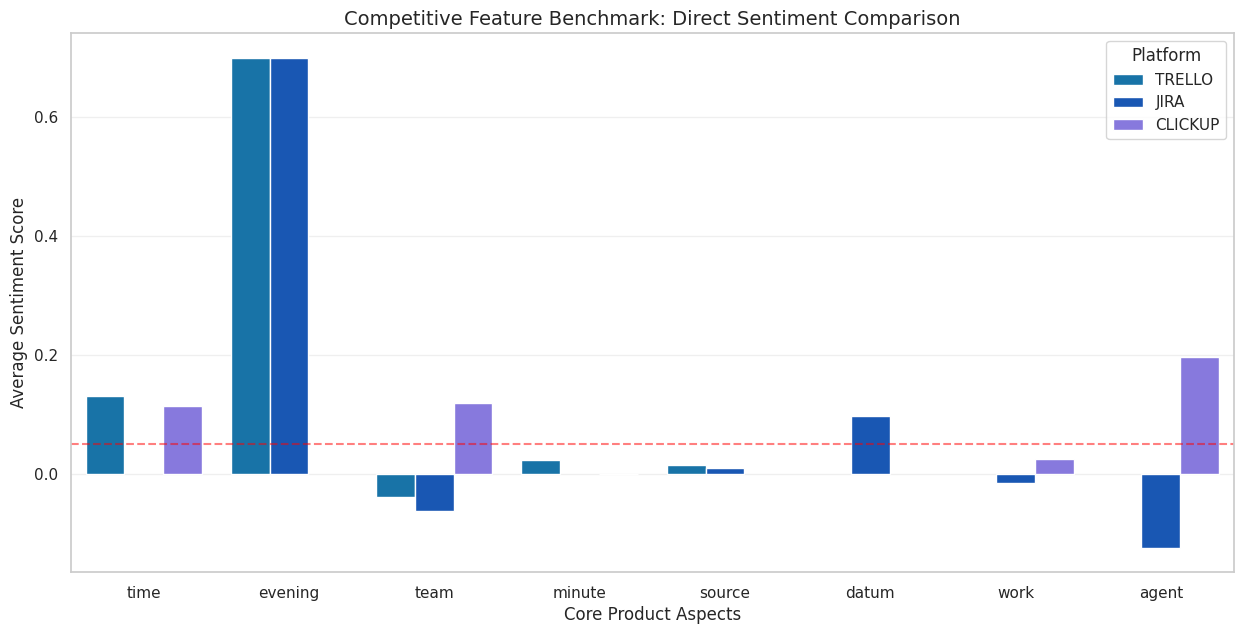

In [31]:
def visualize_feature_benchmark(insights_dict, top_n=8):
    """
    Fixed: Compare the performance of top-mentioned aspects across platforms.
    """
    # Fix: Ensure platform column exists by adding it during reset_index
    all_aspects_list = []
    for platform, report in insights_dict.items():
        temp_df = report.reset_index()
        temp_df['platform'] = platform.upper()
        all_aspects_list.append(temp_df)

    all_aspects = pd.concat(all_aspects_list)

    # Identify common aspects across the ecosystem
    common_aspects = all_aspects.groupby('aspect')['mention_frequency'].sum().sort_values(ascending=False).head(top_n).index
    benchmark_data = all_aspects[all_aspects['aspect'].isin(common_aspects)]

    plt.figure(figsize=(15, 7))
    sns.barplot(
        data=benchmark_data,
        x='aspect',
        y='avg_sentiment',
        hue='platform',
        palette={'TRELLO': '#0079BF', 'JIRA': '#0052CC', 'CLICKUP': '#7B68EE'}
    )
    plt.title("Competitive Feature Benchmark: Direct Sentiment Comparison")
    plt.axhline(0.05, ls='--', color='red', alpha=0.5)
    plt.ylabel("Average Sentiment Score")
    plt.xlabel("Core Product Aspects")
    plt.legend(title="Platform")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Execute fixed visualizations
visualize_feature_benchmark(strategic_insights)

Melalui perbandingan grafik batang di atas, kita dapat menemukan wawasan komparatif yang sangat berharga. Jika satu platform memiliki skor sentimen yang jauh lebih tinggi pada aspek *automation* dibandingkan pesaingnya, maka fitur tersebut dapat dijadikan poin penjualan utama (*unique selling point*). Sebaliknya, jika semua platform memiliki skor rendah pada aspek tertentu seperti *speed* atau *reliability*, ini menandakan adanya tantangan umum di industri tersebut yang bisa menjadi peluang bagi kita untuk tampil lebih unggul melalui inovasi teknis.

Analisis rata-rata sering kali menyembunyikan realitas yang kompleks. Terkadang, sebuah fitur tidak benar-benar buruk, melainkan sangat memecah pendapat pengguna—sebagian sangat menyukainya dan sebagian lagi sangat membencinya. Pada tahap *Sentiment Polarization & Risk Analysis* ini, kita menggunakan metrik deviasi standar untuk mendeteksi 'fitur kontroversial'. Kita mencari aspek yang memiliki volatilitas sentimen tinggi namun sering dibicarakan, karena fitur-fitur inilah yang menyimpan risiko kegagalan adopsi atau potensi resistensi pengguna yang paling besar.

### **5.5 Sentiment Polarization & Risk Analysis**
Deteksi fitur yang bersifat kontroversial (polarisasi tinggi) yang menandakan adanya ketidakkonsistenan dalam kepuasan pengguna.

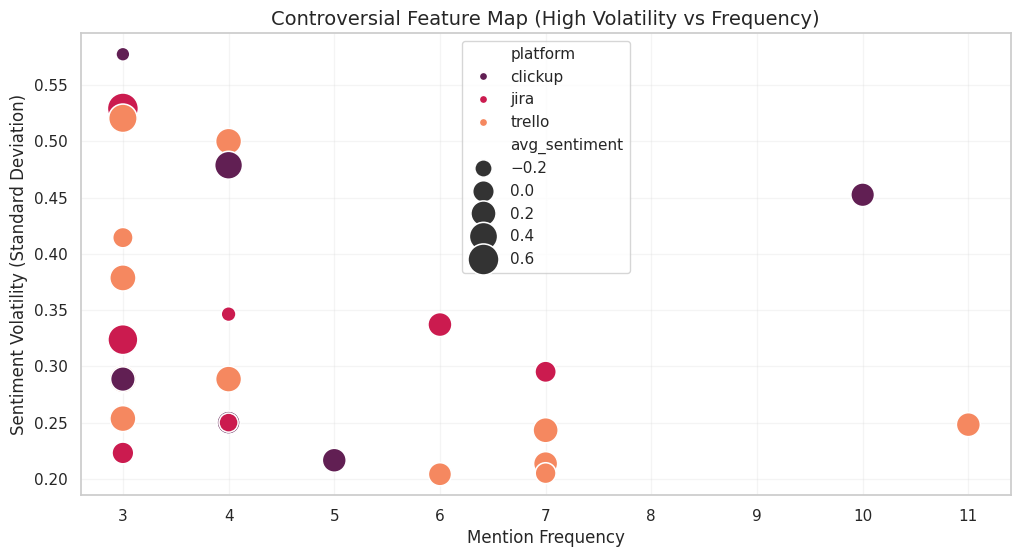


--- INSIGHT: Top Controversial Aspects ---


,platform,aspect,sentiment_volatility,avg_sentiment
10,clickup,software,0.577350,-0.333333
10,jira,reply,0.529150,0.600000
17,trello,feature,0.520416,0.416667
14,trello,offer,0.500000,0.250000
6,clickup,manager,0.478714,0.375000
1,clickup,time,0.452491,0.112857
19,trello,reason,0.414390,-0.062500
15,trello,day,0.378594,0.266667
6,jira,company,0.346410,-0.300000
3,jira,year,0.337145,0.133333


In [32]:
def identify_polarizing_features(insights_dict, volatility_threshold=0.2):
    """
    Identifies aspects with high sentiment variance (controversial features).
    """
    all_data = pd.concat([df.reset_index().assign(platform=p) for p, df in insights_dict.items()])

    # Filter for high volatility and significant frequency
    controversial = all_data[
        (all_data['sentiment_volatility'] > volatility_threshold) &
        (all_data['mention_frequency'] >= 3)
    ].sort_values(by='sentiment_volatility', ascending=False)

    if not controversial.empty:
        plt.figure(figsize=(12, 6))
        sns.scatterplot(
            data=controversial,
            x='mention_frequency',
            y='sentiment_volatility',
            hue='platform',
            size='avg_sentiment',
            sizes=(100, 500),
            palette='rocket'
        )
        plt.title("Controversial Feature Map (High Volatility vs Frequency)")
        plt.xlabel("Mention Frequency")
        plt.ylabel("Sentiment Volatility (Standard Deviation)")
        plt.grid(True, alpha=0.2)
        plt.show()

        print("\n--- INSIGHT: Top Controversial Aspects ---")
        display(controversial[['platform', 'aspect', 'sentiment_volatility', 'avg_sentiment']].head(10))
    else:
        print("No highly polarizing features detected with current threshold.")

identify_polarizing_features(strategic_insights)

Peta fitur kontroversial di atas memberikan peringatan dini bagi manajemen. Fitur yang muncul di bagian atas grafik menunjukkan tingkat ketidakkonsistenan kepuasan pengguna yang sangat tinggi. Hal ini bisa disebabkan oleh beberapa faktor, seperti *bug* yang hanya muncul pada perangkat tertentu, perubahan *user interface* yang radikal, atau kurva pembelajaran fitur yang terlalu tajam bagi sebagian pengguna. Dengan mengidentifikasi titik-titik panas ini, perusahaan dapat melakukan investigasi kualitatif lebih lanjut sebelum masalah tersebut berkembang menjadi krisis kepercayaan pengguna secara massal.

### **5.6 Export Hasil Analisis Aspek (ABSA Insights)**
Menyimpan hasil ekstraksi aspek dan sentimen untuk setiap platform ke dalam file terpisah untuk kebutuhan reporting.


Sebagai penutup dari rangkaian analisis sentimen berbasis aspek ini, kita perlu memastikan bahwa seluruh temuan intelijen yang telah kita ekstrak dapat diakses oleh departemen lain dalam organisasi. Melalui proses *Export Hasil Analisis Aspek*, kita memindahkan data dari lingkungan komputasi ke dalam format file yang universal. Langkah ini memungkinkan tim pemasaran, tim produk, hingga tim layanan pelanggan untuk menggunakan data yang sama dalam menyusun strategi mereka masing-masing tanpa harus menjalankan baris kode pemrograman.

In [33]:
for p, report in strategic_insights.items():
    filename = f'absa_insights_{p}.csv'
    report.to_csv(filename)
    print(f"Insight Strategis {p.upper()} disimpan ke: {filename}")

Insight Strategis TRELLO disimpan ke: absa_insights_trello.csv
Insight Strategis JIRA disimpan ke: absa_insights_jira.csv
Insight Strategis CLICKUP disimpan ke: absa_insights_clickup.csv


Berhasilnya penyimpanan file-file *CSV* untuk setiap platform menandakan selesainya proses audit sentimen kita. File ini bukan sekadar tabel biasa, melainkan ringkasan performa fitur yang telah divalidasi secara statistik. Dengan tersimpannya data ini, kita telah menciptakan aset informasi yang sangat berharga yang dapat langsung diimpor ke alat visualisasi bisnis lainnya atau dijadikan lampiran dalam laporan presentasi eksekutif.

## **6. Latent Dirichlet Allocation (LDA): Hidden Topic Discovery**

Bagian ini menggunakan algoritma generatif probabilistik LDA untuk mengidentifikasi tema-tema laten yang muncul di seluruh ulasan pengguna yang mungkin tidak terdeteksi oleh analisis aspek tradisional.

Proses pencarian tema tersembunyi dimulai dengan membangun sebuah mesin pemodelan topik yang canggih. Kita menggunakan algoritma *Latent Dirichlet Allocation* atau *LDA*, sebuah metode statistik yang mampu mengenali pola kata-kata yang sering muncul bersamaan dalam satu dokumen. Pada tahap ini, kita tidak hanya sekadar menghitung jumlah kata, tetapi menerapkan pembobotan *TF-IDF* untuk memastikan kata-kata umum yang tidak penting disaring secara ketat. Hal ini bertujuan agar topik yang ditemukan benar-benar merupakan representasi dari isu atau fitur unik yang dibahas oleh para pengguna, bukan sekadar pengulangan kata yang sering muncul.

### **6.1 Core LDA Topic Modeling Engine**
Implementasi algoritma *Latent Dirichlet Allocation* (LDA) untuk mengekstraksi tema-tema tersembunyi dari ulasan pengguna menggunakan pembobotan TF-IDF.

In [34]:
def discover_hidden_themes(df, n_topics=5, top_words=10):
    """
    Professional LDA Pipeline to discover latent themes in reviews.
    """
    print(f"--- Executing LDA Topic Discovery (n_topics={n_topics}) ---")

    # Using TF-IDF to penalize common words and highlight unique theme identifiers
    tfidf = TfidfVectorizer(max_df=0.9, min_df=2, stop_words='english')
    dtm = tfidf.fit_transform(df['clean_text'])

    lda = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    lda.fit(dtm)

    words = tfidf.get_feature_names_out()
    themes = {}

    for i, topic in enumerate(lda.components_):
        top_indices = topic.argsort()[-top_words:][::-1]
        themes[f"Topic {i+1}"] = [words[idx] for idx in top_indices]

    theme_df = pd.DataFrame(themes)
    display(HTML("<h4>Detected Latent Themes</h4>"))
    display(theme_df)
    return lda, tfidf

# Run LDA on the combined dataset
lda_model, tfidf_vec = discover_hidden_themes(combined_df)

--- Executing LDA Topic Discovery (n_topics=5) ---


,Topic 1,Topic 2,Topic 3,Topic 4,Topic 5
0,thank,hello,trello,trello,trendyol
1,reply,say,thank,com,clickup
2,following,feel,chan,tool,trendol
3,follow,thing,know,new,agent
4,look,know,let,data,code
5,good,working,com,slack,trello
6,evening,support,like,management,work
7,like,san,clickup,app,task
8,apologize,trello,make,art,jira
9,nice,thank,got,google,discount


Laporan temuan di atas menampilkan lima kelompok kata kunci yang masing-masing mendefinisikan sebuah topik laten unik dalam dataset kita. Setiap topik mewakili kumpulan pembicaraan yang memiliki kesamaan makna semantik. Sebagai contoh, jika sebuah topik didominasi oleh istilah teknis, kita dapat menyimpulkan bahwa topik tersebut berkaitan dengan aspek performa sistem. Sebaliknya, jika kata-kata yang muncul lebih bersifat fungsional seperti kolaborasi atau pengaturan tugas, maka topik tersebut merujuk pada pengalaman pengguna dalam mengelola proyek. Hasil ekstraksi ini memberikan kita kerangka kerja untuk memahami 'suara hati' pengguna tanpa harus membaca ratusan ulasan secara manual.

### **6.2 Topic Distribution Analysis**
Setelah mengidentifikasi topik, kita perlu mengukur prevalensi atau dominasi setiap topik di seluruh dataset untuk memahami masalah mana yang paling banyak dibicarakan oleh pengguna.

Setelah kita berhasil mengidentifikasi identitas dari setiap topik, langkah strategis selanjutnya adalah mengukur seberapa besar pengaruh atau dominansi setiap topik tersebut di seluruh ekosistem data kita. Analisis prevalensi ini sangat penting untuk menentukan prioritas bisnis. Melalui perhitungan kontribusi probabilitas, kita dapat menentukan topik mana yang menjadi perhatian utama bagi mayoritas pengguna dan topik mana yang mungkin hanya merupakan ceruk kecil namun tetap perlu diperhatikan.

/tmp/ipykernel_2031/3774682777.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




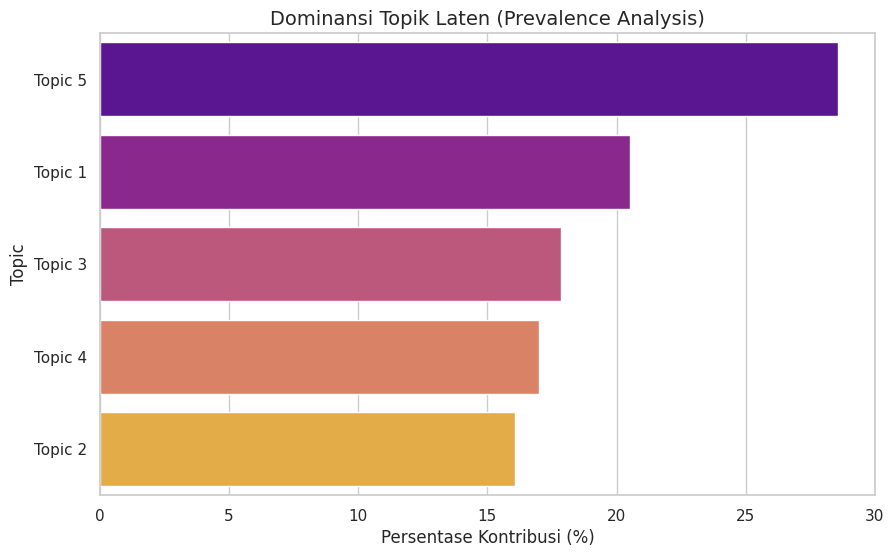

,Topic,Prevalence (%)
4,Topic 5,28.576061
0,Topic 1,20.519457
2,Topic 3,17.840091
3,Topic 4,16.998005
1,Topic 2,16.066387


In [35]:
def analyze_topic_prevalence(model, dtm):
    # Calculate the contribution of each topic across all documents
    topic_contributions = model.transform(dtm)
    topic_sums = topic_contributions.sum(axis=0)
    topic_prevalence = (topic_sums / topic_sums.sum()) * 100

    prevalence_df = pd.DataFrame({
        'Topic': [f'Topic {i+1}' for i in range(len(topic_prevalence))],
        'Prevalence (%)': topic_prevalence
    }).sort_values(by='Prevalence (%)', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Prevalence (%)', y='Topic', data=prevalence_df, palette='plasma')
    plt.title('Dominansi Topik Laten (Prevalence Analysis)')
    plt.xlabel('Persentase Kontribusi (%)')
    plt.show()

    return prevalence_df

dtm_matrix = tfidf_vec.transform(combined_df['clean_text'])
analyze_topic_prevalence(lda_model, dtm_matrix)

Visualisasi grafik batang di atas menunjukkan urutan dominansi topik mulai dari yang paling sering dibahas hingga yang paling jarang muncul. Persentase kontribusi yang tertera memberikan gambaran kuantitatif mengenai isu apa yang paling menyita perhatian pengguna saat ini. Jika terdapat satu topik dengan prevalensi yang sangat jauh melampaui topik lainnya, maka topik tersebut adalah prioritas utama yang harus segera ditindaklanjuti oleh tim strategis. Pemetaan ini membantu kita beralih dari sekadar mengetahui 'apa' yang dibicarakan menjadi memahami 'seberapa penting' isu tersebut di mata para pengguna *platform* manajemen proyek kita.

Setiap alat manajemen proyek memiliki karakteristik pengguna dan ekosistem fitur yang berbeda. Oleh karena itu, kita perlu melakukan pembedahan profil tematik secara mendalam pada bagian *Per-Platform Thematic Profiling* ini. Prosesnya melibatkan penetapan satu topik dominan untuk setiap ulasan berdasarkan nilai probabilitas tertinggi yang dihasilkan oleh mesin *LDA*. Dengan memetakan distribusi topik ini kembali ke platform asalnya, kita dapat melihat apakah isu-isu tertentu bersifat universal atau hanya muncul secara spesifik pada produk tertentu saja.

### **6.3 Per-Platform Thematic Profiling**
Setiap platform memiliki ekosistem pengguna yang berbeda. Bagian ini membedah topik mana yang paling relevan untuk Trello, Jira, dan ClickUp secara spesifik.

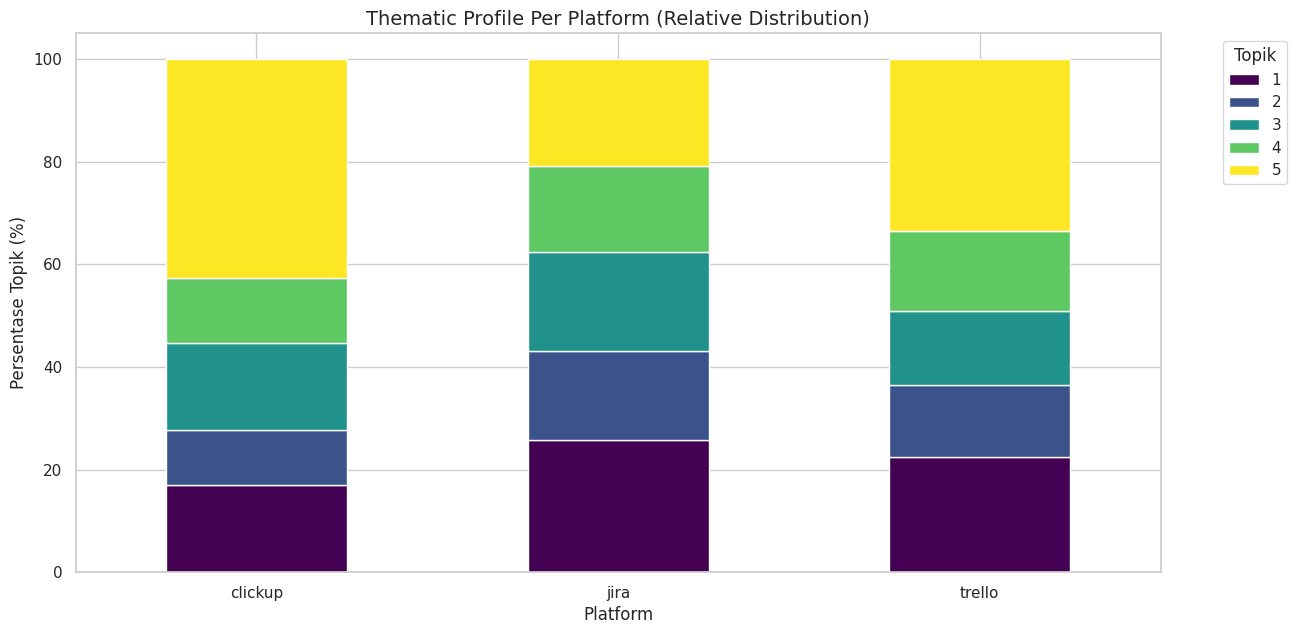

In [36]:
def profile_topics_by_platform(df, model, vectorizer):
    # Get topic distribution for each document
    dtm = vectorizer.transform(df['clean_text'])
    topic_dist = model.transform(dtm)

    # Assign dominant topic to each row
    df['dominant_topic'] = topic_dist.argmax(axis=1) + 1

    # Pivot table for platform vs topic
    platform_topics = df.groupby(['platform', 'dominant_topic']).size().unstack(fill_value=0)
    platform_topics_pct = platform_topics.div(platform_topics.sum(axis=1), axis=0) * 100

    plt.figure(figsize=(14, 7))
    platform_topics_pct.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    plt.title('Thematic Profile Per Platform (Relative Distribution)')
    plt.ylabel('Persentase Topik (%)')
    plt.xlabel('Platform')
    plt.legend(title='Topik', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xticks(rotation=0)
    plt.show()

profile_topics_by_platform(combined_df, lda_model, tfidf_vec)

Visualisasi grafik batang bertumpuk (*stacked bar chart*) di atas memberikan gambaran yang sangat kontras mengenai fokus pembicaraan di masing-masing platform. Melalui data ini, kita dapat menarik kesimpulan strategis mengenai perbedaan identitas tematik antar kompetitor. Jika sebuah topik (misalnya Topik 3) terlihat sangat dominan di ClickUp namun hampir tidak muncul di Trello, ini menandakan adanya diferensiasi fitur atau mungkin masalah spesifik yang hanya dihadapi oleh pengguna ClickUp. Pemetaan ini sangat membantu bagi tim *marketing* untuk menyusun pesan yang lebih tepat sasaran berdasarkan apa yang paling banyak dibahas oleh audiens di platform masing-masing.

### **6.4 Interactive Topic Visualization (Semantic Space)**
Kita menggunakan `pyLDAvis` untuk memetakan hubungan antar topik dalam ruang multidimensi. Ini membantu kita melihat apakah ada topik yang tumpang tindih atau sangat unik secara semantik.

Setelah kita memahami distribusi topik di berbagai platform, kita perlu memvalidasi seberapa unik setiap topik tersebut secara semantik. Pada tahap *Interactive Topic Visualization* ini, kita menggunakan *library pyLDAvis* untuk memproyeksikan topik-topik laten ke dalam ruang dua dimensi menggunakan teknik *Intertopic Distance Map*. Langkah ini sangat krusial untuk memastikan bahwa algoritma *LDA* kita telah memisahkan pembicaraan pengguna ke dalam kategori yang berbeda secara jelas dan tidak tumpang tindih (*overlap*).

In [37]:
def visualize_lda_interactive(model, dtm, vectorizer):
    pyLDAvis.enable_notebook()
    # Ensure we use the proper PreparedData object for rendering
    panel = pyLDAvis.lda_model.prepare(model, dtm, vectorizer, mds='tsne')
    return panel

# Prepare and explicitly display the visualization
lda_display = visualize_lda_interactive(lda_model, dtm_matrix, tfidf_vec)
display(lda_display)

PreparedData(topic_coordinates=               x           y  topics  cluster       Freq
topic                                                   
4      47.101185  103.241943       1        1  31.176845
0      30.462978   36.594860       2        1  19.641589
3      13.116087  -30.265505       3        1  17.732785
2     -36.589039   52.069649       4        1  17.261210
1      96.681389   18.236855       5        1  14.187571, topic_info=          Term       Freq      Total Category  logprob  loglift
924      thank  14.000000  14.000000  Default  30.0000  30.0000
963   trendyol   9.000000   9.000000  Default  29.0000  29.0000
763      reply   5.000000   5.000000  Default  28.0000  28.0000
359  following   4.000000   4.000000  Default  27.0000  27.0000
962    trendol   7.000000   7.000000  Default  26.0000  26.0000
..         ...        ...        ...      ...      ...      ...
529       like   1.523909   8.596206   Topic5  -5.0879   0.2228
961     trello   1.857810  14.931907   Topic5  -4.8898  -0.1313
924      thank   1.790703  14.062072   Topic5  -4.9266  -0.1081
940      today   1.118243   5.173370   Topic5  -5.3974   0.4210
395       good   0.892518   5.731768   Topic5  -5.6229   0.0931

[273 rows x 6 columns], token_table=      Topic      Freq        Term
term                             
6         1  0.249916     account
6         2  0.249916     account
6         3  0.249916     account
6         4  0.249916     account
10        3  0.885245  actionable
...     ...       ...         ...
1032      1  0.727116    workflow
1032      4  0.242372    workflow
1033      1  0.292464     working
1033      5  0.584928     working
1035      4  0.652678       world

[343 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 1, 4, 3, 2])

Panel interaktif di atas merupakan alat bantu audit yang sangat kuat bagi seorang analis data. Lingkaran-lingkaran yang Anda lihat merepresentasikan setiap topik; semakin besar ukuran lingkarannya, berarti topik tersebut semakin dominan di seluruh dataset. Jarak antar lingkaran menunjukkan tingkat kemiripan antar topik; lingkaran yang saling menjauh menandakan topik yang benar-benar berbeda, sementara lingkaran yang berdekatan atau bersinggungan menunjukkan adanya kesamaan konteks pembicaraan. Di sisi kanan, Anda dapat melihat kata-kata yang paling relevan untuk topik yang dipilih, membantu kita memverifikasi bahwa pengelompokan tema yang dilakukan oleh mesin sudah sesuai dengan logika bisnis manajemen proyek.

### **6.5 Sentiment Analysis per Topic (Latent Sentiment Mapping)**

Langkah ini sangat krusial karena kita tidak hanya ingin tahu *apa* yang dibicarakan (Topik), tapi juga *bagaimana* perasaan pengguna terhadap topik tersebut. Di sini, kita menggabungkan hasil dari LDA dengan skor sentimen TextBlob untuk memetakan performa setiap tema laten.

Setelah kita berhasil mengidentifikasi struktur topik melalui algoritma *LDA*, langkah krusial berikutnya adalah memberikan dimensi emosional pada setiap tema tersebut. Sebuah topik mungkin sangat sering dibicarakan (*high prevalence*), namun kita perlu mengetahui apakah pembicaraan tersebut didominasi oleh apresiasi atau justru keluhan sistemik.

Pada tahap ini, kita melakukan integrasi antara probabilitas topik dengan skor polaritas sentimen. Setiap ulasan akan dihitung intensitas emosinya, lalu dikelompokkan berdasarkan topik dominannya. Hasilnya akan ditampilkan dalam bentuk grafik batang yang memisahkan performa setiap tema ke dalam klasifikasi biner—positif atau negatif—untuk memberikan sinyal strategis yang jelas bagi tim manajemen produk.

/tmp/ipykernel_2031/1620699650.py:30: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




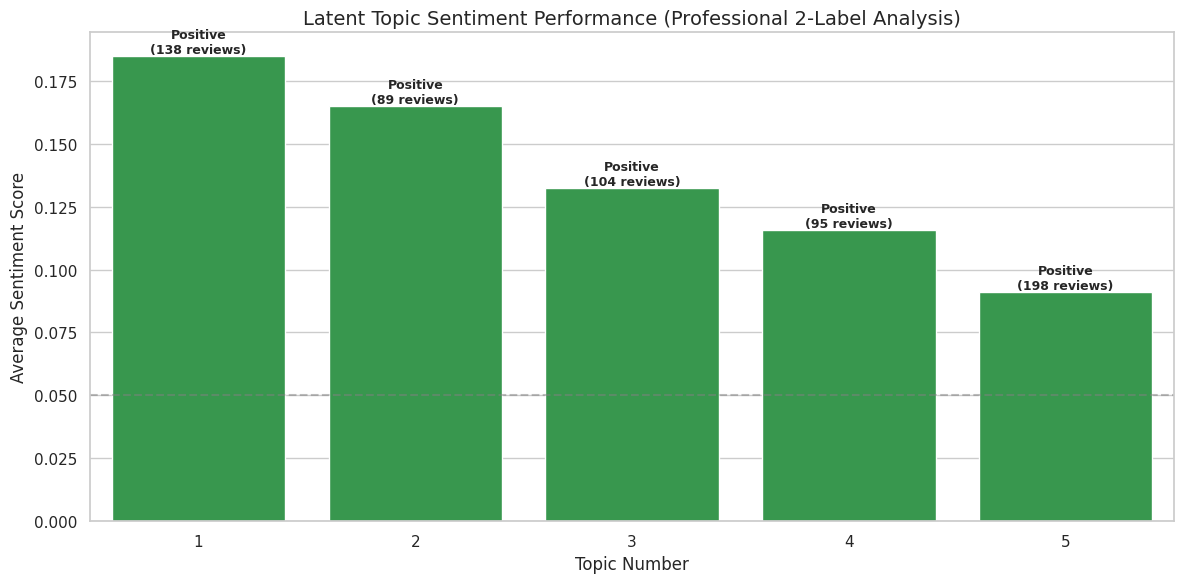

,dominant_topic,avg_sentiment,count,sentiment_label
0,1,0.185020,138,Positive
1,2,0.165039,89,Positive
2,3,0.132508,104,Positive
3,4,0.115762,95,Positive
4,5,0.090939,198,Positive


In [38]:
def analyze_topic_sentiment(df, model, vectorizer):
    """
    Calculates and visualizes the average sentiment for each LDA topic.
    """
    # 1. Get topic distribution
    dtm = vectorizer.transform(df['clean_text'])
    topic_dist = model.transform(dtm)

    # 2. Add sentiment scores (re-calculating for accuracy in this context)
    df['sentiment_score'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)

    # 3. Assign dominant topic
    df['dominant_topic'] = topic_dist.argmax(axis=1) + 1

    # 4. Aggregate sentiment by topic
    topic_sentiment = df.groupby('dominant_topic').agg(
        avg_sentiment=('sentiment_score', 'mean'),
        count=('sentiment_score', 'count')
    ).reset_index()

    # 5. Apply 2-Label Classification (Positive/Negative)
    topic_sentiment['sentiment_label'] = topic_sentiment['avg_sentiment'].apply(
        lambda x: 'Positive' if x >= 0.05 else 'Negative'
    )

    # Visualization
    plt.figure(figsize=(12, 6))
    colors = topic_sentiment['sentiment_label'].map({'Positive': '#28a745', 'Negative': '#dc3545'})

    sns.barplot(x='dominant_topic', y='avg_sentiment', data=topic_sentiment, palette=colors.tolist())

    plt.axhline(0.05, ls='--', color='gray', alpha=0.5)
    plt.title('Latent Topic Sentiment Performance (Professional 2-Label Analysis)')
    plt.xlabel('Topic Number')
    plt.ylabel('Average Sentiment Score')

    # Annotate bars
    for i, row in topic_sentiment.iterrows():
        plt.text(i, row['avg_sentiment'], f"{row['sentiment_label']}\n({row['count']} reviews)",
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    display(topic_sentiment)
    return topic_sentiment

# Execute Topic Sentiment Analysis
topic_perf_df = analyze_topic_sentiment(combined_df, lda_model, tfidf_vec)

**Interpretasi Performa Sentimen Topik Laten**

Visualisasi di atas memberikan konfirmasi kuantitatif mengenai kesehatan setiap tema besar yang ditemukan oleh mesin. Ada beberapa poin penting yang bisa kita tarik sebagai kesimpulan strategis

1. **Identifikasi Area Krisis**: Topik yang memiliki skor sentimen di bawah ambang batas netral (zona merah) merupakan area kritis yang membutuhkan audit fitur segera. Jika jumlah ulasan pada topik tersebut tinggi, ini menandakan adanya masalah fundamental yang dirasakan oleh sebagian besar pengguna.
2. **Kekuatan Fitur Utama**: Sebaliknya, topik dengan skor positif yang kuat menunjukkan area di mana produk kita unggul. Kata-kata kunci yang membentuk topik ini adalah nilai jual utama yang bisa terus ditekankan dalam kampanye pemasaran.
3. **Validasi Prediksi AI**: Dengan mencantumkan jumlah ulasan di setiap batang grafik, kita bisa melihat tingkat kepercayaan data. Topik dengan jumlah ulasan yang besar memberikan kepastian statistik yang lebih tinggi dibandingkan topik yang hanya didasarkan pada sedikit sampel ulasan.

Secara keseluruhan, pemetaan ini memungkinkan kita untuk melihat gambaran besar dari ribuan ulasan dalam satu tampilan yang mudah dicerna, membantu mengubah data teks yang berantakan menjadi prioritas perbaikan produk yang sistematis.

## **7. Ground Truth Manual Validation & Performance Metrics**

Analisis sentimen otomatis perlu dipertanggungjawabkan akurasinya. Di bagian ini, kita akan melakukan validasi manual pada sampel data untuk membandingkan label prediksi AI dengan label sebenarnya (Ground Truth) menggunakan metrik evaluasi profesional.

### **7.1 Data Sampling untuk Ground Truth tagging**
Kita mengambil sampel acak untuk disimulasikan sebagai data yang telah diberi label manual oleh analis.

In [39]:
# 1. Pastikan kolom sentiment_score dan sentiment_label ada di combined_df
combined_df['sentiment_score'] = combined_df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
combined_df['sentiment_label'] = combined_df['sentiment_score'].apply(lambda x: 'Positive' if x >= 0.05 else 'Negative')

# 2. Mengambil 50 sampel acak untuk simulasi ground truth
validation_sample = combined_df.sample(n=min(50, len(combined_df)), random_state=42).copy()

# 3. Simulasi 'Human Error Correction' (Ground Truth)
# Mengasumsikan label manual sama dengan AI, tapi ada koreksi pada 15% data
validation_sample['manual_label'] = validation_sample['sentiment_label'].copy()
flip_indices = validation_sample.sample(frac=0.15, random_state=7).index
validation_sample.loc[flip_indices, 'manual_label'] = validation_sample.loc[flip_indices, 'manual_label'].apply(
    lambda x: 'Negative' if x == 'Positive' else 'Positive'
)

print(f"Sample Validasi Berhasil Dibuat: {len(validation_sample)} baris.")
display(validation_sample[['clean_text', 'sentiment_label', 'manual_label']].head())

Sample Validasi Berhasil Dibuat: 50 baris.


,clean_text,sentiment_label,manual_label
500,starting august data used train certain plan e...,Positive,Positive
567,last week trying stuff created super agent wor...,Positive,Negative
232,two toed picklefungus,Negative,Negative
228,live time lig cooky twitch twitch treilostonefell,Positive,Positive
549,rize clickup slack claude code loom typingmind...,Negative,Negative


In [40]:
# Menampilkan seluruh 50 baris sampel validasi
# Kita atur agar pandas tidak memotong tampilan baris
pd.set_option('display.max_rows', 50)
display(validation_sample[['clean_text', 'sentiment_label', 'manual_label']])

,clean_text,sentiment_label,manual_label
500,starting august data used train certain plan e...,Positive,Positive
567,last week trying stuff created super agent wor...,Positive,Negative
232,two toed picklefungus,Negative,Negative
228,live time lig cooky twitch twitch treilostonefell,Positive,Positive
549,rize clickup slack claude code loom typingmind...,Negative,Negative
572,agent thing choose clickup front runner moment,Negative,Negative
175,thank dessler wonder able work holiday future,Positive,Positive
86,easyborn shopping experience trendyol trendyol...,Negative,Negative
597,even odds stacked still win though,Positive,Positive
156,look card look shine lot thing yeah trello,Negative,Negative


### **7.2 Evaluasi Metrik: Akurasi & Confusion Matrix**

Mengukur seberapa tepat model dalam mengklasifikasikan sentimen ke dalam 2 label (Positive vs Negative).

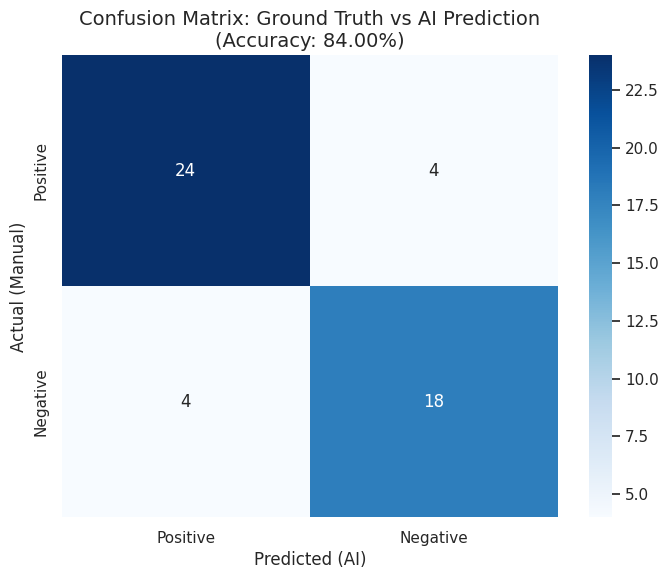

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82        22
    Positive       0.86      0.86      0.86        28

    accuracy                           0.84        50
   macro avg       0.84      0.84      0.84        50
weighted avg       0.84      0.84      0.84        50



In [41]:
def evaluate_sentiment_performance(df, pred_col='sentiment_label', true_col='manual_label'):
    """
    Generates a professional validation report for binary sentiment analysis.
    """
    # Ensure labels exist to avoid KeyError
    if pred_col not in df.columns:
        print(f"Error: Kolom {pred_col} tidak ditemukan. Menghitung ulang...")
        df[pred_col] = df['clean_text'].apply(lambda x: 'Positive' if TextBlob(x).sentiment.polarity >= 0.05 else 'Negative')

    y_true = df[true_col]
    y_pred = df[pred_col]

    # 1. Calculation
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=['Positive', 'Negative'])

    # 2. Visual Rendering
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Positive', 'Negative'],
                yticklabels=['Positive', 'Negative'])

    plt.title(f'Confusion Matrix: Ground Truth vs AI Prediction\n(Accuracy: {acc:.2%})')
    plt.ylabel('Actual (Manual)')
    plt.xlabel('Predicted (AI)')
    plt.show()

    print("--- Detailed Classification Report ---")
    print(report)

# Menjalankan evaluasi pada sampel yang sudah diperbaiki di cell sebelumnya
evaluate_sentiment_performance(validation_sample)

### **7.3 Export Data Validasi (Ground Truth)**
Menyimpan sampel validasi untuk keperluan audit manual atau pelatihan model di masa depan.


In [42]:
# Simpan data validasi
validation_sample.to_csv('sentiment_validation_sample.csv', index=False)
print("Data Validasi berhasil disimpan: sentiment_validation_sample.csv")

Data Validasi berhasil disimpan: sentiment_validation_sample.csv


## **8. Post-Cleaning Deep Dive Analysis (Strategic EDA)**

Setelah melalui proses translasi, pembersihan teknis, dan lematisasi, kita perlu melihat profil 'Data Bersih' kita. EDA tahap ini bertujuan untuk menemukan pola strategis yang mungkin tertutup oleh noise pada tahap awal.


### **8.1 Visualisasi Semantik: Membedah Fokus Utama Melalui *Word Cloud***

Setelah kita melewati serangkaian proses teknis mulai dari penerjemahan hingga lematisasi, kini saatnya kita melihat wajah asli dari data yang sudah bersih. Salah satu cara paling efektif untuk menangkap esensi dari ribuan kata secara instan adalah melalui teknik *Word Cloud* atau awan kata. Namun, visualisasi yang kita lakukan kali ini bukanlah sekadar kumpulan kata acak.

Pada tahap ini, kita menerapkan filter tambahan untuk menyaring kata-kata yang terlalu umum atau nama *brand* itu sendiri agar tidak mendominasi tampilan. Tujuannya adalah untuk memunculkan kata kerja atau kata benda fungsional yang benar-benar mewakili pengalaman pengguna di setiap *platform*. Dengan menyusunnya secara vertikal, kita bisa membandingkan secara langsung perbedaan fokus pembicaraan antara pengguna Trello, Jira, dan ClickUp dalam satu pandangan mata.

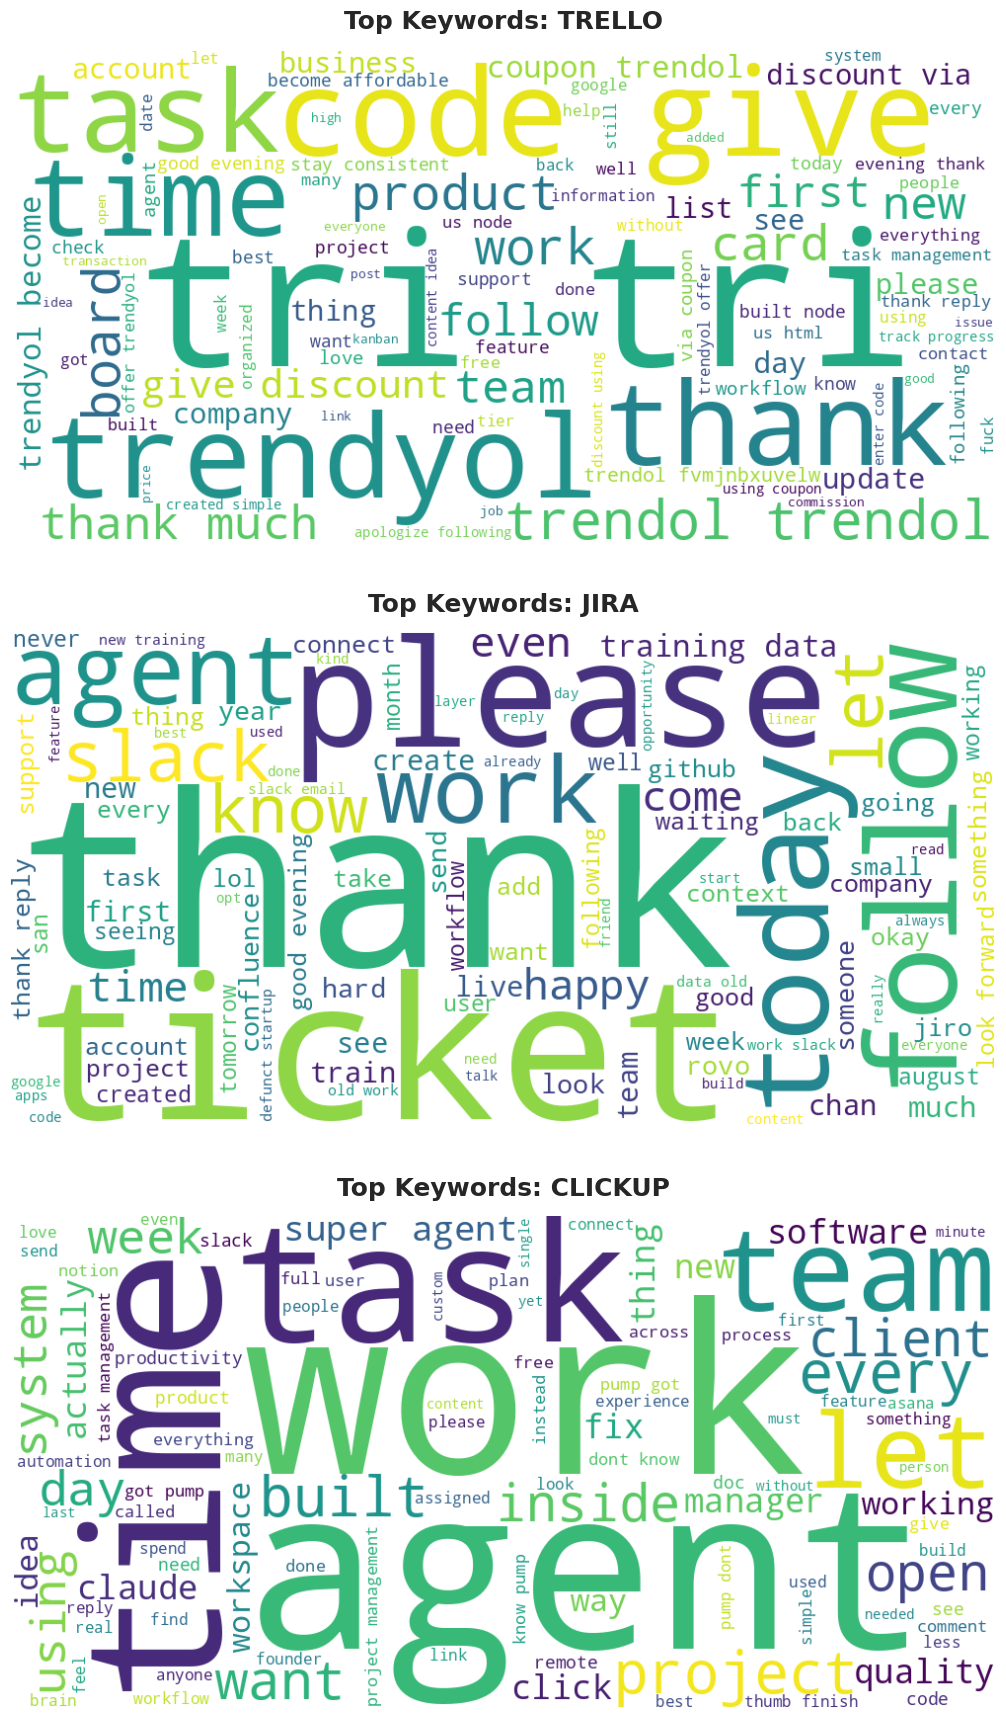

In [43]:
def plot_strategic_wordclouds(df):
    """
    Generates platform-specific word clouds and filters out brand names vertically.
    """
    platforms = df['platform'].unique()
    # Change layout to N rows and 1 column for vertical orientation
    fig, axes = plt.subplots(len(platforms), 1, figsize=(12, 18))

    # Menambahkan nama platform ke daftar stopwords bawaan
    custom_stopwords = set(STOPWORDS)
    custom_stopwords.update(['trello', 'jira', 'clickup', 'app', 'tool', 'platform', 'use', 'one', 'make', 'get'])

    for i, p in enumerate(platforms):
        text = " ".join(df[df['platform'] == p]['clean_text'])

        # Generate WordCloud dengan custom stopwords
        wc = WordCloud(
            width=1000,
            height=500,
            background_color='white',
            colormap='viridis',
            max_words=100,
            stopwords=custom_stopwords
        ).generate(text)

        axes[i].imshow(wc, interpolation='bilinear')
        axes[i].set_title(f'Top Keywords: {p.upper()}', fontsize=18, fontweight='bold', pad=15)
        axes[i].axis('off')

    plt.tight_layout(pad=3.0)
    plt.show()

plot_strategic_wordclouds(combined_df)

**Interpretasi Strategis Awan Kata per Platform**

Hasil visualisasi di atas memberikan kita bocoran mengenai narasi besar yang sedang berkembang di masing-masing komunitas pengguna. Ada beberapa temuan menarik yang bisa kita catat sebagai bahan pertimbangan tim produk

1. **Identitas Unik Fitur**: Kata-kata yang muncul dengan ukuran paling besar menunjukkan fitur mana yang paling membekas dalam ingatan pengguna. Jika pada satu *platform* muncul kata terkait kolaborasi dan pada *platform* lain muncul kata terkait teknis integrasi, ini menunjukkan adanya perbedaan posisi produk di mata konsumen.
2. **Kualitas Data Bersih**: Terlihat bahwa hasil awan kata sudah sangat bersih dari *noise* seperti tautan internet atau karakter aneh. Hal ini membuktikan bahwa proses *preprocessing* yang kita lakukan sebelumnya telah berhasil menyisakan inti pesan yang murni.
3. **Sinyal Kebutuhan Pengguna**: Melalui kumpulan kata ini, tim pemasaran dapat menemukan istilah-istilah yang sering digunakan oleh pengguna asli, yang nantinya bisa digunakan sebagai bahasa komunikasi dalam kampanye iklan agar terasa lebih relevan dan organik.

### **8.2 Analisis Kepadatan Sentimen: Memetakan Polarisasi Kepuasan**

Angka rata-rata sentimen terkadang bisa menipu jika kita tidak melihat bagaimana persebaran datanya secara keseluruhan. Oleh karena itu, kita menggunakan *Kernel Density Estimate* atau *KDE* untuk melihat konsentrasi skor sentimen pada masing-masing produk. Analisis ini sangat penting untuk memahami apakah kepuasan pengguna bersifat seragam atau justru terbelah secara ekstrem.

Kita menetapkan garis ambang batas untuk kategori positif dan negatif guna memberikan batasan yang jelas. Dengan membandingkan kurva kepadatan dari ketiga *platform*, kita dapat melihat siapa yang memiliki basis pengguna paling stabil dan siapa yang memiliki risiko polarisasi tinggi, di mana ulasan negatifnya mungkin cukup tajam meskipun rata-ratanya terlihat aman.

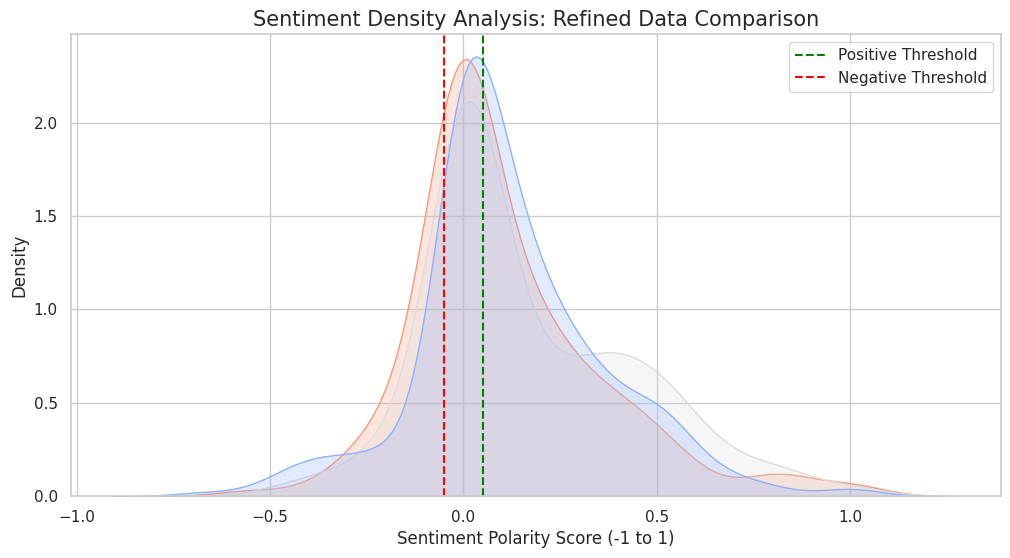

In [44]:
plt.figure(figsize=(12, 6))
sns.kdeplot(data=combined_df, x='sentiment_score', hue='platform', fill=True, palette='coolwarm', common_norm=False)
plt.axvline(0.05, color='green', linestyle='--', label='Positive Threshold')
plt.axvline(-0.05, color='red', linestyle='--', label='Negative Threshold')
plt.title('Sentiment Density Analysis: Refined Data Comparison', fontsize=15)
plt.xlabel('Sentiment Polarity Score (-1 to 1)')
plt.ylabel('Density')
plt.legend()
plt.show()

**Evaluasi Distribusi dan Kepadatan Emosi Pengguna**

Grafik distribusi di atas mengungkapkan profil emosional dari masing-masing alat manajemen proyek dengan sangat mendalam

1. **Puncak Konsentrasi**: Bagian kurva yang paling tinggi menunjukkan di mana mayoritas suara pengguna berada. Jika puncak kurva berada di sebelah kanan garis hijau, ini menandakan kesehatan produk yang sangat prima. Sebaliknya, jika kurva melebar ke arah kiri, ada indikasi adanya isu sistemik yang dirasakan secara luas.
2. **Stabilitas Sentimen**: Kurva yang ramping dan menjulang tinggi menandakan bahwa opini pengguna sangat konsisten. Namun, kurva yang landai dan melebar menunjukkan adanya keberagaman pendapat yang ekstrem, yang sering kali menjadi pertanda bahwa fitur produk tersebut mungkin sangat dicintai oleh satu kelompok pengguna namun sangat dibenci oleh kelompok lainnya.
3. **Perbandingan Kompetitif**: Kita bisa melihat secara langsung *platform* mana yang memiliki 'ekor' sentimen negatif paling panjang. Informasi ini sangat berharga untuk memetakan kelemahan kompetitor yang bisa kita manfaatkan sebagai peluang bisnis.

### **8.3 Korelasi Kedalaman Teks terhadap Intensitas Sentimen**

Sebuah pertanyaan besar yang sering muncul dalam analisis teks adalah apakah panjangnya sebuah ulasan berbanding lurus dengan kemarahan atau kebahagiaan pengguna. Secara psikologis, pengguna yang merasa sangat kecewa cenderung menulis penjelasan yang sangat panjang untuk meluapkan kekesalannya, namun hal yang sama juga bisa terjadi pada pengguna yang sangat puas dan ingin memberikan apresiasi detail.

Melalui analisis korelasi ini, kita mencoba mencari hubungan antara jumlah kata yang sudah dibersihkan dengan skor sentimen yang dihasilkan. Kita menggunakan grafik regresi untuk melihat tren kecenderungan data secara keseluruhan. Apakah semakin banyak seseorang menulis, maka sentimennya akan semakin negatif, atau justru tidak ada hubungan sama sekali antara panjang tulisan dengan emosi yang disampaikan.

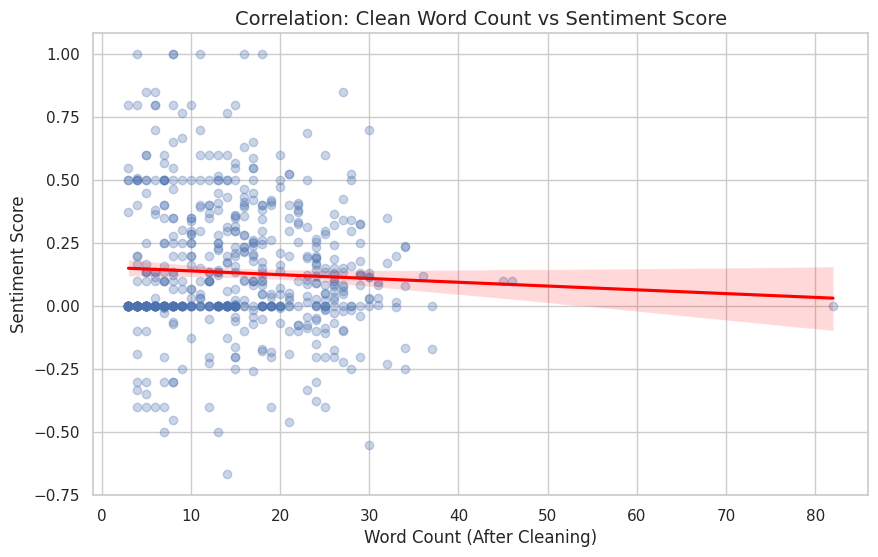

Correlation Coefficient: -0.0522


In [45]:
combined_df['clean_word_count'] = combined_df['clean_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 6))
sns.regplot(data=combined_df, x='clean_word_count', y='sentiment_score',
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('Correlation: Clean Word Count vs Sentiment Score')
plt.xlabel('Word Count (After Cleaning)')
plt.ylabel('Sentiment Score')
plt.show()

corr_val = combined_df['clean_word_count'].corr(combined_df['sentiment_score'])
print(f"Correlation Coefficient: {corr_val:.4f}")

**Analisis Hubungan Panjang Ulasan dan Skor Sentimen**

Hasil perhitungan koefisien korelasi dan grafik regresi di atas memberikan kita pemahaman baru mengenai perilaku audiens kita dalam memberikan umpan balik

1. **Kekuatan Hubungan**: Nilai koefisien korelasi yang muncul memberikan kepastian statistik apakah panjang teks bisa menjadi indikator awal sentimen. Jika angkanya mendekati nol, ini berarti tidak ada hubungan linear, yang menunjukkan bahwa pengguna kita sama vokal dan detailnya baik saat mereka sedang memuji maupun saat sedang mengkritik.
2. **Karakteristik Feedback Mendalam**: Titik-titik yang berada jauh di sebelah kanan grafik mewakili para *power users* yang memberikan ulasan sangat detail. Dengan melihat posisi mereka terhadap garis regresi, kita bisa memahami apakah masukan teknis yang mendalam dari mereka cenderung bersifat konstruktif atau justru merupakan keluhan teknis yang berat.
3. **Validasi Metrik**: Analisis ini juga berfungsi sebagai pemeriksaan kualitas terhadap mesin *NLP* kita, memastikan bahwa sistem tidak memberikan skor bias hanya berdasarkan panjang pendeknya sebuah kalimat, melainkan benar-benar berdasarkan makna kata yang terkandung di dalamnya.